In [213]:
# Import libraries
import pandas as pd
import numpy as np
import ast
import re
import math
from geopy.geocoders import Nominatim
# libraries for displaying images
from IPython.display import Image 
from IPython.core.display import HTML 
from folium.plugins import FloatImage
import folium # plotting library

import matplotlib.pyplot as plt
import seaborn as sns

# Plotly
from plotly.offline import init_notebook_mode, plot, iplot
import plotly.graph_objs as go
import plotly.plotly as py
init_notebook_mode(connected=True)
%matplotlib inline

In [ ]:
rest_df = pd.read_csv(r"C:\Users\Himanshu Poddar\Desktop\zomato.csv", encoding='utf-8')

Lets drop duplicates based on the value from two columns address and name

In [5]:
rest_df = rest_df.drop_duplicates(subset=['address', 'name']).reset_index().drop('index', axis=1)

In [4]:
rest_df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


<b>Some of our dish_liked rows are empty, lets extract the dish liked in a restaurant from the reviews in restaurant, All the reviews that were >=3 will be used.</b>

First let us make food corpus for our data


Since the column reviews_list, menu_item are in the form of list of tuples but as we read it from file we need to explicitly convert it to list


In [310]:
rest_df['reviews_list'] =  rest_df['reviews_list'].apply(ast.literal_eval)
rest_df['menu_item'] =  rest_df['menu_item'].apply(ast.literal_eval)

In [311]:
li = []
def func(x):
    global li
    li = li + x
_ = rest_df[rest_df['menu_item']!="[]"]['menu_item'].apply(func)

In [312]:
# convert all the menu to lower case letter and storing in the variable food_corpus
food_corpus = list(map(str.lower, set(li)))

On analysing the corpus it was found that some food contains quantity written beside it inside the brackets.<br>
Let us remove those brackets.

In [313]:
menu_corpus = []
for x in food_corpus:
    menu_corpus.append(re.sub("\[.*\]|\(.*\)", "", x).strip())

In [314]:
len(menu_corpus)

71170

Very well, so we have 71,110 food items in our corpus. But there is no data without noise, let us remove noise from it.

Lets analyse the data, for the words that frequently occur and are not a food item.

In [ ]:
ind = rest_df[rest_df['reviews_list']!="[]"].index
for i in ind:
    liked = set()
    for review in rest_df.loc[i,'reviews_list']:
        if(float(review[0].replace('Rated ',''))>=3):
            for menu in menu_corpus:
                if(menu in review[1]):
                    liked.add(menu)
    print(liked)

After analysing the above output these were some of the frequent non menu words found.

In [315]:
remove_words = ['poi', 'spite', 'churi', 'peni', 'packing', 'meal', 'malt', 'smilies', 'disco', 'tac', 'cap', 'spicy', 'last night', 'cop', 
'brain', 'onion', 'spice', 'holige', 'adas', 'sulaimani', 'special', 'combo 4', 'toppings', 'smile', 'water', 'ghee', '',
'mixed', 'slice', 'lunch', 'masala c', 'churi', 'breakfast combo', 'undo', 'full meal', 'fanta', 'cool blue', 'love', 'veg lovers',
'irish', 'fried', 'mast', 'rose', 'overload']

In [316]:
# Lets remove them from our corpus first
new_menu_corpus = [word for word in menu_corpus if word not in remove_words]

In [317]:
len(new_menu_corpus)

71111

In [320]:
# perfect now those noise are removed, let us extract menus from review and store it in the column liked_food_from_review

rest_df['liked_food_from_review'] = rest_df['liked_food_from_review'].astype(object)
rest_df['liked_food_from_review'] = "[]"

In [ ]:
ind = rest_df[rest_df['reviews_list']!="[]"].index
for i in ind:
    
    liked = set()
    for review in rest_df.loc[i,'reviews_list']:
        if(review[0]!=None and float(review[0].replace('Rated ',''))>=3):
            for menu in new_menu_corpus:
                if(menu in review[1]):
                    liked.add(menu)
    rest_df.loc[i,'liked_food_from_review'] = str(list(liked))

In [11]:
rest_df['liked_food_from_review'] =  rest_df['liked_food_from_review'].apply(ast.literal_eval)

In [5]:
# Now that we have liked food for a restaurant, lets see
rest_df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city),liked_food_from_review
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775.0,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari,"['fried rice', 'soya chaap', 'kulcha', 'rice',..."
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787.0,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari,"['chicken', 'fried rice', 'chicken biryan', 'c..."
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918.0,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari,"['veggies', 'egg', 'pasta', 'cake', 'chocolate..."
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88.0,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari,"['pulka', 'apple', 'rice with sambar', 'dosa',..."
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166.0,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari,"['roti', 'noodles', 'kulcha', 'pav bhaji', 'pa..."


In [6]:
# Also lets convert dishes from our dish_liked column to lower case letters
rest_df['dish_liked'] = rest_df['dish_liked'].str.lower()

In [12]:
# Also lets split dish_liked
rest_df['menus_combined'] = rest_df['dish_liked'].str.split()+ rest_df['liked_food_from_review']

### Exploratory Data Analysis

How many different restaurants are there in Bengaluru

In [ ]:
histo = rest_df.groupby('name')['address'].count()
# Lets take the top 50 restaurantsand plot bar graph
histo = histo.sort_values()[-50:]

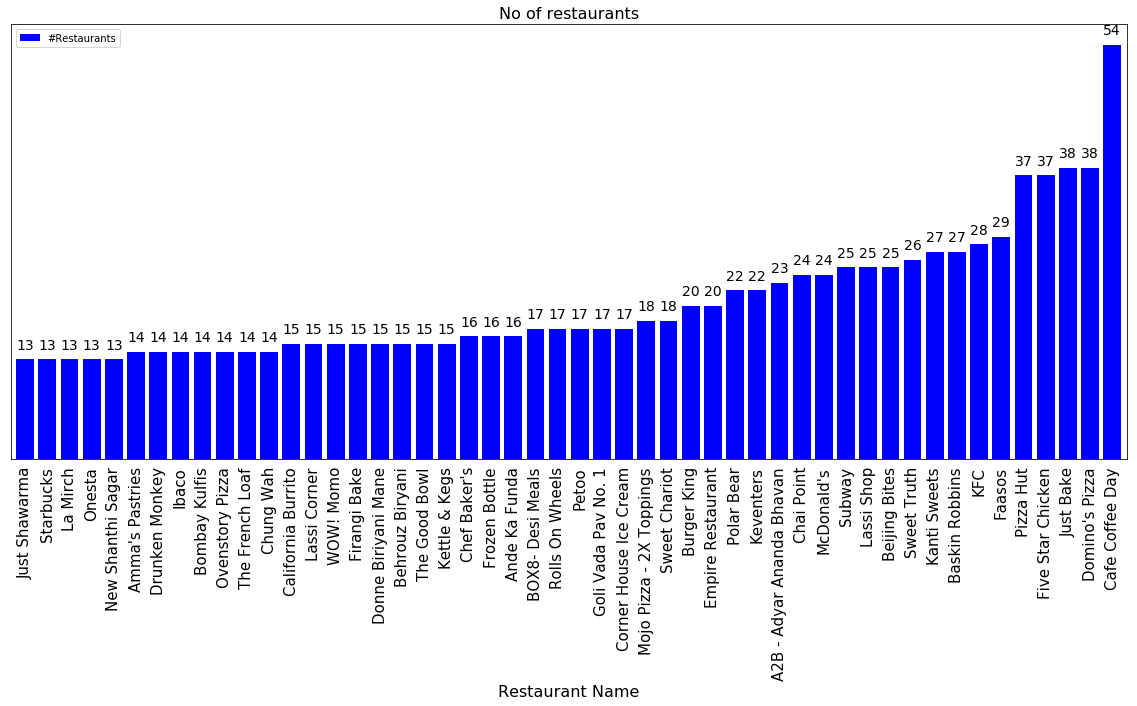

In [31]:
ax = histo.plot(kind='bar', figsize=(20, 8), rot=90, width = 0.8, color=[ 'blue'])
rects = ax.patches
labels = list(histo)
for rect, label in zip(rects, labels):
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width() / 2, height + 1, label,
            ha='center', va='bottom', fontsize=14)
ax.tick_params(top='off', bottom='off', left='off', right='off', labelleft='off', labelbottom='on') # remove borders
ax.xaxis.set_tick_params(labelsize=15) # set xticks as 14
ax.legend(fontsize=14) # set legend sie as 14
ax.set_title('No of restaurants', fontsize=16) # set title and add font size as 16
ax.set_xlabel('Restaurant Name', fontsize=16)
#ax.grid(False)  # remove grid
ax.set_facecolor("white") # set bg color white
ax.legend(['#Restaurants'])

In [ ]:
from subprocess import check_output
from wordcloud import WordCloud
wordcloud = (WordCloud(width=1440, height=1080, relative_scaling=0.5).generate_from_frequencies(rest_df['name'].value_counts()))


fig = plt.figure(1,figsize=(15, 15))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

<img src="https://i.ibb.co/sw1PSWv/wordcloud.png" alt="wordcloud" height="1500" width="1500">

Clearly CCD(Cafe) has the most number of restaurants in Bengaluru, followed by Domino's Pizza

### Delivery Restaurant and Table Book

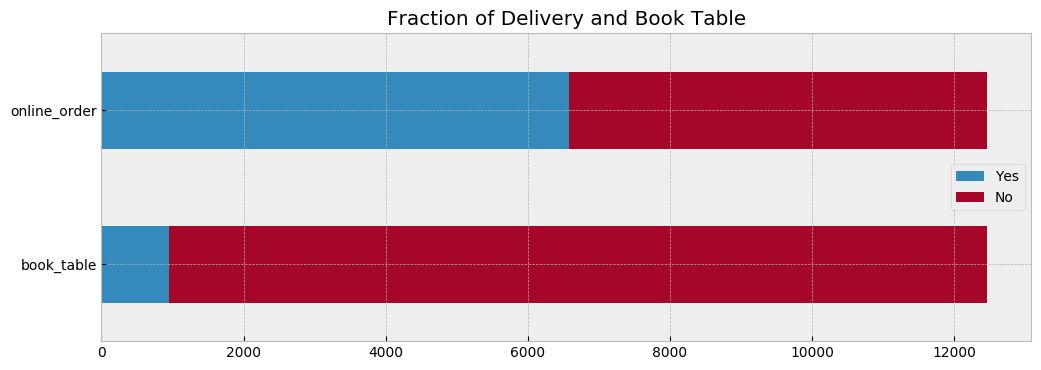

In [121]:
with plt.style.context('bmh', after_reset = True):
    plt.figure(figsize = (12,4))
    ax = plt.subplot(1,1,1)
    tmp = {}
    for col in ['online_order', 'book_table']: 
        tmp[col] = rest_df[col].value_counts()
    tmp = pd.DataFrame.from_dict(tmp, orient = 'index')
    tmp.plot.barh(stacked = True, ax = ax)
    ax.set_title('Fraction of Delivery and Book Table')
    plt.show()


#### Lets take the rating of restaurant and find the average rating for each of the neighborhood

In [151]:
rest_df['rate'] = rest_df['rate'].str.split('/').str[0]

Lets set the rating of new restaurants as NULL

In [154]:
rest_df.loc[rest_df['rate']=="NEW", 'rate'] = np.nan
rest_df.loc[rest_df['rate']=="-", 'rate'] = np.nan

In [155]:
rest_df['rate'] = rest_df['rate'].astype('float')

In [75]:
rest_df.groupby(['location'])['rate'].mean().sort_values()[-50:][:-1]

location
Whitefield               3.548363
HBR Layout               3.553333
Basaveshwara Nagar       3.554167
Rajajinagar              3.562500
Old Airport Road         3.566116
Mysore Road              3.566667
Koramangala 1st Block    3.569600
Banashankari             3.570683
JP Nagar                 3.577262
Koramangala 2nd Block    3.577778
HSR                      3.585231
Vijay Nagar              3.588462
Kammanahalli             3.597080
Yelahanka                3.600000
Frazer Town              3.614189
New BEL Road             3.614348
Basavanagudi             3.622396
Sahakara Nagar           3.629268
Koramangala 8th Block    3.643750
Brigade Road             3.646018
Ulsoor                   3.647917
Langford Town            3.650000
Kalyan Nagar             3.676098
Koramangala 6th Block    3.686525
Malleshwaram             3.692925
Vasanth Nagar            3.697778
Kengeri                  3.700000
Central Bangalore        3.700000
Koramangala              3.716667
Jayan

Clearly Lavelle Road restaurants are rated higher

### Number of restaurants in each Neighborhood

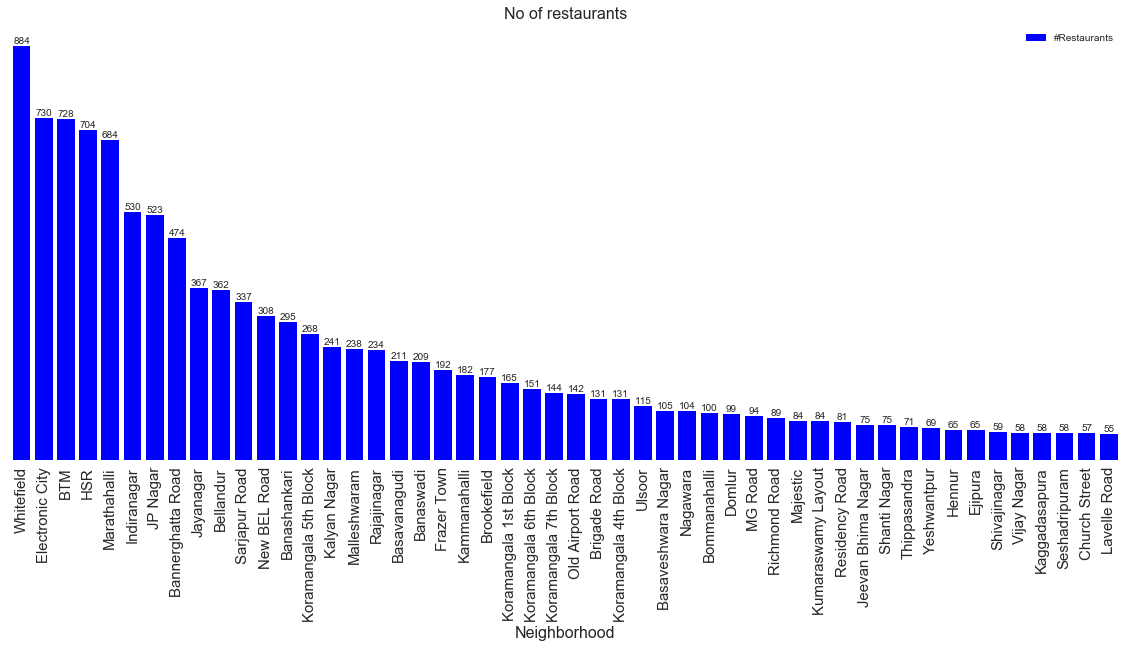

In [363]:
histo = rest_df.groupby('location')['url'].count().sort_values(ascending=False)[:50]
ax = histo.plot(kind='bar', figsize=(20, 8), rot=90, width = 0.8, color=[ 'blue'])
rects = ax.patches
labels = list(histo)
for rect, label in zip(rects, labels):
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width() / 2, height + .05, label,
            ha='center', va='bottom', fontsize=10)
ax.tick_params(top='off', bottom='off', left='off', right='off', labelleft='off', labelbottom='on') # remove borders
ax.xaxis.set_tick_params(labelsize=15) # set xticks as 14
ax.legend(fontsize=14) # set legend sie as 14
ax.set_title('No of restaurants', fontsize=16) # set title and add font size as 16
ax.set_xlabel('Neighborhood', fontsize=16)
#ax.grid(False)  # remove grid
ax.set_facecolor("white") # set bg color white
ax.legend(['#Restaurants'])

Whitefield has the highest number of restaurants followed by EC

### Zomato's Presence across Bangalore

In [216]:
labels = list(rest_df.location.value_counts().index)
values = list(rest_df.location.value_counts().values)

fig = {
    "data":[
        {
            "labels" : labels,
            "values" : values,
            "hoverinfo" : 'label+percent',
            "domain": {"x": [0, .9]},
            "hole" : 0.6,
            "type" : "pie",
            "rotation":120,
        },
    ],
    "layout": {
        "title" : "Zomato's Presence in Bangalore",
        "annotations": [
            {
                "font": {"size":20},
                "showarrow": True,
                "text": "Neighborhood",
                "x":0.2,
                "y":0.9,
            },
        ]
    }
}

iplot(fig)

### Lets get the coordinates for each of the neighborhood

In [31]:
location = [x for x in rest_df['location'].unique().tolist() if type(x) == str]
latitude = []
longitude =  []
for i in range(0, len(location)):
    if(type(location[i]) == str):
        ctr=0
        while True:
            try:
                address = location[i] + ', Bengaluru, India'
                geolocator = Nominatim(user_agent="ny_explorer")
                loc = geolocator.geocode(address)
                latitude.append(loc.latitude)
                longitude.append(loc.longitude)
                print('The geograpical coordinate of location are {}, {}.'.format(loc.latitude, loc.longitude))
            except:
                ctr+=1
                if(ctr==7):
                    print(i)
                    latitude.append(address)
                    longitude.append(address)
                    break
                continue
            break

The geograpical coordinate of location are 12.91538175, 77.5736376995009.
The geograpical coordinate of location are 12.9417261, 77.5755021.
The geograpical coordinate of location are 12.9597523, 77.5561291.
The geograpical coordinate of location are 12.9292731, 77.5824229.
The geograpical coordinate of location are 12.9068169, 77.5635247362134.
The geograpical coordinate of location are 12.9274278, 77.5153722.
The geograpical coordinate of location are 12.96627425, 77.6127051647936.
The geograpical coordinate of location are 12.9055682, 77.5455438.
The geograpical coordinate of location are 12.9072515, 77.5782713.
The geograpical coordinate of location are 12.9791198, 77.5912997.
The geograpical coordinate of location are 12.965718, 77.5762705372058.
The geograpical coordinate of location are 12.9651008, 77.5078635.
The geograpical coordinate of location are 12.9205791, 77.6001168.
The geograpical coordinate of location are 12.91127585, 77.6045654343118.
The geograpical coordinate of 

In [92]:
rest_df['location_latitude'] = rest_df['location'].map(dict(zip(location, latitude)))
rest_df['location_longitude'] = rest_df['location'].map(dict(zip(location, longitude)))

In [217]:
dataframe_filtered = rest_df.groupby(['location'])['location_latitude', 'location_longitude'].first()
dataframe_filtered['no_restaurant'] = rest_df.groupby(['location'])['url'].count()
venues_map = folium.Map(location=[12.934533, 77.626579], zoom_start=11) # generate map centred around Bengaluru

states = folium.map.FeatureGroup()
i=0
for lat, lng, in zip(dataframe_filtered.location_latitude, dataframe_filtered.location_longitude):
    states.add_child(
        folium.features.CircleMarker(
            [lat, lng],
            radius=5, # define how big you want the circle markers to be
            color='yellow',
            fill=True,
            fill_color='blue',
            fill_opacity=0.6,
        )
    )
    i+=1
i=0
for lat, lng, in zip(dataframe_filtered.location_latitude, dataframe_filtered.location_longitude):
    states.add_child(
        folium.features.Marker(
            [lat, lng],
            popup= dataframe_filtered.index[i],
        )
    )
    i+=1
# add incidents to map
venues_map.add_child(states)
venues_map

### Plot map by density of restaurants in each neighborhood

In [219]:
bins = pd.IntervalIndex.from_tuples([(0, 100), (101, 200), (201, 300), (301, 400), (401, 500), (501, 600), (601, 700), (701, 800), (801, 900)])
dataframe_filtered['category'] = pd.cut(dataframe_filtered['no_restaurant'], bins)

In [220]:
x = dataframe_filtered.groupby('category').groups.keys()

In [221]:
venues_map = folium.Map(location=[12.934533, 77.626579], zoom_start=11) # generate map centred around Bengaluru

states = folium.map.FeatureGroup()
i=0
for lat, lng, in zip(dataframe_filtered.location_latitude, dataframe_filtered.location_longitude):
    states.add_child(
        folium.features.CircleMarker(
            [lat, lng],
            radius=5, # define how big you want the circle markers to be
            color='yellow',
            fill=True,
            fill_color='blue',
            fill_opacity=0.6,
        )
    )
    i+=1
colors = ['red', 'blue', 'green', 'purple', 'orange', 'white', 'pink', 'gray', 'black']
j=0
for i in range(0,len(list(x))):
    group = dataframe_filtered.groupby('category').get_group(list(x)[i])
    i=0
    for lat, lng, in zip(group.location_latitude, group.location_longitude):
        states.add_child(
            folium.features.Marker(
                [lat, lng],
                popup= group.index[i],
                icon=folium.Icon(color=colors[j], icon='cloud')
            )
        )
        i+=1
    j+=1
# add incidents to map
venues_map.add_child(states)

# url = ('https://raw.githubusercontent.com/SECOORA/static_assets/'
#        'master/maps/img/rose.png')
# FloatImage(image_file, bottom=40, left=65).add_to(venues_map)
from branca.element import Template, MacroElement

template = """
{% macro html(this, kwargs) %}

<!doctype html>
<html lang="en">
<head>
  <meta charset="utf-8">
  <meta name="viewport" content="width=device-width, initial-scale=1">
  <title>jQuery UI Draggable - Default functionality</title>
  <link rel="stylesheet" href="//code.jquery.com/ui/1.12.1/themes/base/jquery-ui.css">

  <script src="https://code.jquery.com/jquery-1.12.4.js"></script>
  <script src="https://code.jquery.com/ui/1.12.1/jquery-ui.js"></script>
  
  <script>
  $( function() {
    $( "#maplegend" ).draggable({
                    start: function (event, ui) {
                        $(this).css({
                            right: "auto",
                            top: "auto",
                            bottom: "auto"
                        });
                    }
                });
});

  </script>
</head>
<body>

 
<div id='maplegend' class='maplegend' 
    style='position: absolute; z-index:9999; border:2px solid grey; background-color:rgba(255, 255, 255, 0);
     border-radius:6px; padding: 10px; font-size:14px; right: 20px; bottom: 20px;'>
     
<div class='legend-title'>Number of restaurants</div>
<div class='legend-scale'>
  <ul class='legend-labels'>
    <li><span style='background:red;opacity:0.7;'></span>0-100</li>
    <li><span style='background:blue;opacity:0.7;'></span>101-200</li>
    <li><span style='background:green;opacity:0.7;'></span>201-300</li>
    <li><span style='background:purple;opacity:0.7;'></span>301-400</li>
    <li><span style='background:orange;opacity:0.7;'></span>401-500</li>
    <li><span style='background:white;opacity:0.7;'></span>501-600</li>
    <li><span style='background:pink;opacity:0.7;'></span>601-700</li>
    <li><span style='background:gray;opacity:0.7;'></span>701-800</li>
    <li><span style='background:black;opacity:0.7;'></span>801-900</li>
  </ul>
</div>
</div>
 
</body>
</html>

<style type='text/css'>
  .maplegend .legend-title {
    text-align: left;
    margin-bottom: 5px;
    font-weight: bold;
    font-size: 90%;
    }
  .maplegend .legend-scale ul {
    margin: 0;
    margin-bottom: 5px;
    padding: 0;
    float: left;
    list-style: none;
    }
  .maplegend .legend-scale ul li {
    font-size: 80%;
    list-style: none;
    margin-left: 0;
    line-height: 18px;
    margin-bottom: 2px;
    }
  .maplegend ul.legend-labels li span {
    display: block;
    float: left;
    height: 16px;
    width: 30px;
    margin-right: 5px;
    margin-left: 0;
    border: 1px solid #999;
    }
  .maplegend .legend-source {
    font-size: 80%;
    color: #777;
    clear: both;
    }
  .maplegend a {
    color: #777;
    }
</style>
{% endmacro %}"""

macro = MacroElement()
macro._template = Template(template)

venues_map.get_root().add_child(macro)

venues_map


It can be seen clearly that outer cities of Bengaluru has most number of restaurants. But wait is that true ?<br>
Analysing the data we found that central bengaluru is densely populated while there aren't much markers at the outer part of the city.

### Neighborhood by rating

In [222]:
nb_rate_df = rest_df.groupby(['location'])['location_latitude', 'location_longitude'].first()
nb_rate_df['rate'] = rest_df.groupby(['location'])['rate'].mean()
nb_rate_df

,location_latitude,location_longitude,rate
location,,,
BTM,12.911276,77.604565,3.556950
Banashankari,12.915382,77.573638,3.625991
Banaswadi,13.014162,77.651854,3.477397
Bannerghatta Road,12.920579,77.600117,3.476000
Basavanagudi,12.941726,77.575502,3.675141
Basaveshwara Nagar,12.993224,77.539158,3.595522
Bellandur,12.979120,77.591300,3.493436
Bommanahalli,12.908945,77.623904,3.218519
Brigade Road,12.973613,77.607472,3.675926


In [223]:
bins = pd.IntervalIndex.from_tuples([(3.2, 3.3), (3.31, 3.4), (3.41, 3.5), (3.51, 3.6), (3.61, 3.7), (3.71, 3.8), (3.81, 3.9), (3.91, 4.0), (4.0, 4.1)])
nb_rate_df['category'] = pd.cut(nb_rate_df['rate'], bins)

In [224]:
x = nb_rate_df.groupby('category').groups.keys()

In [225]:
venues_map = folium.Map(location=[12.934533, 77.626579], zoom_start=11) # generate map centred around Bengaluru

states = folium.map.FeatureGroup()
i=0
for lat, lng, in zip(nb_rate_df.location_latitude, nb_rate_df.location_longitude):
    states.add_child(
        folium.features.CircleMarker(
            [lat, lng],
            radius=5, # define how big you want the circle markers to be
            color='yellow',
            fill=True,
            fill_color='blue',
            fill_opacity=0.6,
        )
    )
    i+=1
colors = ['red', 'blue', 'green', 'purple', 'orange', 'white', 'pink', 'gray', 'black']
j=0
for i in range(0,len(list(x))):
    group = nb_rate_df.groupby('category').get_group(list(x)[i])
    i=0
    for lat, lng, in zip(group.location_latitude, group.location_longitude):
        states.add_child(
            folium.features.Marker(
                [lat, lng],
                popup= group.index[i],
                icon=folium.Icon(color=colors[j], icon='cloud')
            )
        )
        i+=1
    j+=1
# add incidents to map
venues_map.add_child(states)

# url = ('https://raw.githubusercontent.com/SECOORA/static_assets/'
#        'master/maps/img/rose.png')
# FloatImage(image_file, bottom=40, left=65).add_to(venues_map)
from branca.element import Template, MacroElement

template = """
{% macro html(this, kwargs) %}

<!doctype html>
<html lang="en">
<head>
  <meta charset="utf-8">
  <meta name="viewport" content="width=device-width, initial-scale=1">
  <title>jQuery UI Draggable - Default functionality</title>
  <link rel="stylesheet" href="//code.jquery.com/ui/1.12.1/themes/base/jquery-ui.css">

  <script src="https://code.jquery.com/jquery-1.12.4.js"></script>
  <script src="https://code.jquery.com/ui/1.12.1/jquery-ui.js"></script>
  
  <script>
  $( function() {
    $( "#maplegend" ).draggable({
                    start: function (event, ui) {
                        $(this).css({
                            right: "auto",
                            top: "auto",
                            bottom: "auto"
                        });
                    }
                });
});

  </script>
</head>
<body>

 
<div id='maplegend' class='maplegend' 
    style='position: absolute; z-index:9999; border:2px solid grey; background-color:rgba(255, 255, 255, 0);
     border-radius:6px; padding: 10px; font-size:14px; right: 20px; bottom: 20px;'>
     
<div class='legend-title'>Number of restaurants</div>
<div class='legend-scale'>
  <ul class='legend-labels'>
    <li><span style='background:red;opacity:0.7;'></span>3.2-3.3</li>
    <li><span style='background:blue;opacity:0.7;'></span>3.31-3.4</li>
    <li><span style='background:green;opacity:0.7;'></span>3.41-3.5</li>
    <li><span style='background:purple;opacity:0.7;'></span>3.51-3.6</li>
    <li><span style='background:orange;opacity:0.7;'></span>3.61-3.7</li>
    <li><span style='background:white;opacity:0.7;'></span>3.71-3.8</li>
    <li><span style='background:pink;opacity:0.7;'></span>3.81-3.9</li>
    <li><span style='background:gray;opacity:0.7;'></span>3.91-4.0</li>
    <li><span style='background:black;opacity:0.7;'></span>4.04.1</li>
  </ul>
</div>
</div>
 
</body>
</html>

<style type='text/css'>
  .maplegend .legend-title {
    text-align: left;
    margin-bottom: 5px;
    font-weight: bold;
    font-size: 90%;
    }
  .maplegend .legend-scale ul {
    margin: 0;
    margin-bottom: 5px;
    padding: 0;
    float: left;
    list-style: none;
    }
  .maplegend .legend-scale ul li {
    font-size: 80%;
    list-style: none;
    margin-left: 0;
    line-height: 18px;
    margin-bottom: 2px;
    }
  .maplegend ul.legend-labels li span {
    display: block;
    float: left;
    height: 16px;
    width: 30px;
    margin-right: 5px;
    margin-left: 0;
    border: 1px solid #999;
    }
  .maplegend .legend-source {
    font-size: 80%;
    color: #777;
    clear: both;
    }
  .maplegend a {
    color: #777;
    }
</style>
{% endmacro %}"""

macro = MacroElement()
macro._template = Template(template)

venues_map.get_root().add_child(macro)

venues_map


Most of the top rated restaurants are clustered around Central Bengaluru

### Neighborhood by cost of food

#### Lets see the cost of food in each neighborhood of Bengaluru

In [ ]:
rest_df['approx_cost(for two people)'] = rest_df['approx_cost(for two people)'].str.replace(",","").astype(float)

But before that lets remove all those places that has less than 50 restaurants

In [228]:
above_50 = rest_df.groupby('location')['url'].count()[rest_df.groupby('location')['url'].count() >= 50].index

##### Does this mean higher the cost of food means posche area

In [229]:
rest_df[rest_df['location'].isin(above_50)].groupby('location')['approx_cost(for two people)'].mean().sort_values(ascending= False)

location
Lavelle Road             1292.727273
MG Road                  1052.127660
Residency Road            949.382716
Church Street             762.280702
Richmond Road             736.516854
Seshadripuram             733.620690
Vasanth Nagar             719.444444
Ulsoor                    687.280702
Old Airport Road          637.304965
Indiranagar               601.064639
Koramangala 4th Block     595.038168
Brigade Road              594.122137
Koramangala 5th Block     578.113208
Whitefield                558.293515
Domlur                    553.020833
Koramangala 6th Block     548.666667
Koramangala 7th Block     525.524476
Kalyan Nagar              523.941909
Sarjapur Road             489.071856
Marathahalli              485.315712
Malleshwaram              484.117647
Bellandur                 481.712707
Electronic City           461.714678
JP Nagar                  457.777778
Jayanagar                 444.277929
HSR                       440.285307
New BEL Road              435

Cost of living in Lavelle Road is also quite high, even I can't afford the restaurants in lavelle road

<font size=2px><b> Lets see it on the map</b></font>

In [230]:
nb_cost_df = rest_df.groupby(['location'])['location_latitude', 'location_longitude'].first()
nb_cost_df['cost'] = rest_df.groupby(['location'])['approx_cost(for two people)'].mean()
nb_cost_df

,location_latitude,location_longitude,cost
location,,,
BTM,12.911276,77.604565,378.815427
Banashankari,12.915382,77.573638,380.101695
Banaswadi,13.014162,77.651854,378.921569
Bannerghatta Road,12.920579,77.600117,423.340381
Basavanagudi,12.941726,77.575502,339.620853
Basaveshwara Nagar,12.993224,77.539158,397.572816
Bellandur,12.979120,77.591300,481.712707
Bommanahalli,12.908945,77.623904,398.676768
Brigade Road,12.973613,77.607472,594.122137


In [231]:
bins = pd.IntervalIndex.from_tuples([(200, 600), (601, 1000), (1001, 1400), (2201, 2600)])
nb_cost_df['category'] = pd.cut(nb_cost_df['cost'], bins)

In [232]:
x = nb_cost_df.groupby('category').groups.keys()
venues_map = folium.Map(location=[12.934533, 77.626579], zoom_start=11) # generate map centred around Bengaluru

states = folium.map.FeatureGroup()
i=0
for lat, lng, in zip(nb_cost_df.location_latitude, nb_cost_df.location_longitude):
    states.add_child(
        folium.features.CircleMarker(
            [lat, lng],
            radius=5, # define how big you want the circle markers to be
            color='yellow',
            fill=True,
            fill_color='blue',
            fill_opacity=0.6,
        )
    )
    i+=1
colors = ['red', 'blue', 'green', 'purple', 'orange', 'black']
j=0
for i in range(0,len(list(x))):
    group = nb_cost_df.groupby('category').get_group(list(x)[i])
    i=0
    for lat, lng, in zip(group.location_latitude, group.location_longitude):
        states.add_child(
            folium.features.Marker(
                [lat, lng],
                popup= group.index[i],
                icon=folium.Icon(color=colors[j], icon='cloud')
            )
        )
        i+=1
    j+=1
# add incidents to map
venues_map.add_child(states)

# url = ('https://raw.githubusercontent.com/SECOORA/static_assets/'
#        'master/maps/img/rose.png')
# FloatImage(image_file, bottom=40, left=65).add_to(venues_map)
from branca.element import Template, MacroElement

template = """
{% macro html(this, kwargs) %}

<!doctype html>
<html lang="en">
<head>
  <meta charset="utf-8">
  <meta name="viewport" content="width=device-width, initial-scale=1">
  <title>jQuery UI Draggable - Default functionality</title>
  <link rel="stylesheet" href="//code.jquery.com/ui/1.12.1/themes/base/jquery-ui.css">

  <script src="https://code.jquery.com/jquery-1.12.4.js"></script>
  <script src="https://code.jquery.com/ui/1.12.1/jquery-ui.js"></script>
  
  <script>
  $( function() {
    $( "#maplegend" ).draggable({
                    start: function (event, ui) {
                        $(this).css({
                            right: "auto",
                            top: "auto",
                            bottom: "auto"
                        });
                    }
                });
});

  </script>
</head>
<body>

 
<div id='maplegend' class='maplegend' 
    style='position: absolute; z-index:9999; border:2px solid grey; background-color:rgba(255, 255, 255, 0);
     border-radius:6px; padding: 10px; font-size:14px; right: 20px; bottom: 20px;'>
     
<div class='legend-title'>Cost</div>
<div class='legend-scale'>
  <ul class='legend-labels'>
    <li><span style='background:red;opacity:0.7;'></span>200-600</li>
    <li><span style='background:blue;opacity:0.7;'></span>601-1000</li>
    <li><span style='background:green;opacity:0.7;'></span>1001-1400</li>
    <li><span style='background:purple;opacity:0.7;'></span>2201-2600</li>
  </ul>
</div>
</div>
</body>
</html>

<style type='text/css'>
  .maplegend .legend-title {
    text-align: left;
    margin-bottom: 5px;
    font-weight: bold;
    font-size: 90%;
    }
  .maplegend .legend-scale ul {
    margin: 0;
    margin-bottom: 5px;
    padding: 0;
    float: left;
    list-style: none;
    }
  .maplegend .legend-scale ul li {
    font-size: 80%;
    list-style: none;
    margin-left: 0;
    line-height: 18px;
    margin-bottom: 2px;
    }
  .maplegend ul.legend-labels li span {
    display: block;
    float: left;
    height: 16px;
    width: 30px;
    margin-right: 5px;
    margin-left: 0;
    border: 1px solid #999;
    }
  .maplegend .legend-source {
    font-size: 80%;
    color: #777;
    clear: both;
    }
  .maplegend a {
    color: #777;
    }
</style>
{% endmacro %}"""

macro = MacroElement()
macro._template = Template(template)

venues_map.get_root().add_child(macro)

venues_map


It can be seen that all the costly restaurants are located in Central Bangalore, Lavelle Road, MG Road, Race Course Road.

Yes it can therefore be said from higher cost of food means posche area comparing it to the ground truth of Bangalore

### Grouping the neighborhood by the type of restaurant 

In [300]:
types = set()
def func(x):
    if(type(x) == list):
        print(x)
        for y in x:
            types.add(y.strip())
_ = rest_df['rest_type'].str.split(',').apply(func)

In [284]:
column_names = list(types)
# instantiate the dataframe
neighborhood = pd.DataFrame(columns=column_names)
neighborhood

,Pop Up,Bhojanalya,Pub,Lounge,Microbrewery,Bar,Quick Bites,Takeaway,Fine Dining,Delivery,...,Meat Shop,Cafe,Food Truck,Casual Dining,Kiosk,Confectionery,Club,Bakery,Mess,Dessert Parlor


In [285]:
neighborhood['neighborhood'] = rest_df.groupby('location').groups.keys()
neighborhood = neighborhood.set_index('neighborhood').fillna(0)
neighborhood

,Pop Up,Bhojanalya,Pub,Lounge,Microbrewery,Bar,Quick Bites,Takeaway,Fine Dining,Delivery,...,Meat Shop,Cafe,Food Truck,Casual Dining,Kiosk,Confectionery,Club,Bakery,Mess,Dessert Parlor
neighborhood,,,,,,,,,,,,,,,,,,,,,
BTM,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Banashankari,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Banaswadi,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Bannerghatta Road,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Basavanagudi,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Basaveshwara Nagar,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Bellandur,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Bommanahalli,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Brigade Road,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [286]:
i=0
for i in range(0,len(rest_df)):
    for x in types:
        if type(rest_df.loc[i, 'rest_type']) == str and x in rest_df.loc[i, 'rest_type']:
            neighborhood.loc[rest_df.loc[i, 'location'], x] = neighborhood.loc[rest_df.loc[i, 'location'], x]+1

In [289]:
# Koramangala is divided into different block, lets combine them all
koramangala = ['Koramangala', 'Koramangala 1st Block', 'Koramangala 2nd Block', 'Koramangala 3rd Block', 'Koramangala 4th Block', 
'Koramangala 5th Block', 'Koramangala 6th Block', 'Koramangala 7th Block', 'Koramangala 8th Block']
koramangala_dict = dict(neighborhood.loc[koramangala].sum())
neighborhood = neighborhood.drop(koramangala)
neighborhood.loc['Koramangala'] = koramangala_dict

In [290]:
neighborhood

,Pop Up,Bhojanalya,Pub,Lounge,Microbrewery,Bar,Quick Bites,Takeaway,Fine Dining,Delivery,...,Meat Shop,Cafe,Food Truck,Casual Dining,Kiosk,Confectionery,Club,Bakery,Mess,Dessert Parlor
neighborhood,,,,,,,,,,,,,,,,,,,,,
BTM,0,0,1,0,1,7,404,72,0,115,...,0,28,0,91,2,0,0,17,2,25
Banashankari,0,0,1,1,0,6,162,13,0,25,...,0,25,0,42,0,1,0,9,2,20
Banaswadi,0,0,1,0,0,4,114,8,0,15,...,0,11,0,39,2,1,0,8,3,5
Bannerghatta Road,0,0,1,2,1,3,207,30,0,61,...,0,19,0,90,4,1,0,19,1,32
Basavanagudi,0,0,1,0,0,4,128,2,0,2,...,0,9,0,33,1,0,0,14,0,20
Basaveshwara Nagar,0,0,1,0,0,2,54,4,0,13,...,0,5,0,20,0,0,0,4,0,12
Bellandur,0,0,2,2,0,6,138,31,0,55,...,0,16,0,83,5,0,1,19,6,21
Bommanahalli,0,0,0,0,0,1,55,7,0,18,...,0,1,0,14,0,0,0,4,2,0
Brigade Road,0,0,5,1,2,6,44,1,0,1,...,0,11,0,40,4,0,1,5,0,14


#### Swarm plot

In [291]:
dfs = neighborhood.reset_index().melt('neighborhood', var_name='cols',  value_name='vals')

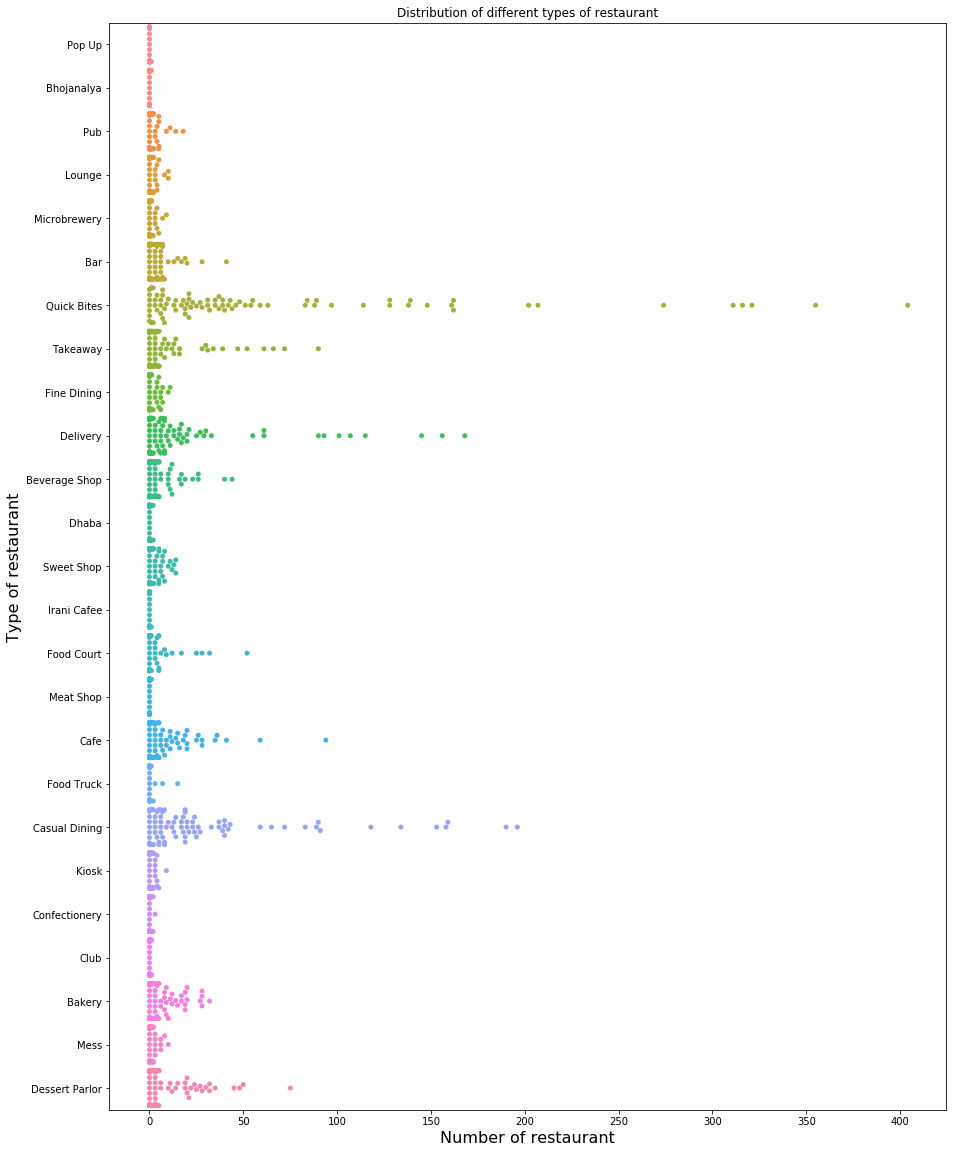

In [292]:
plt.figure(figsize=(15,20))
ax = sns.swarmplot(x="vals", y="cols", data=dfs)
ax.set_xlabel('Number of restaurant', fontsize=16)
ax.set_ylabel('Type of restaurant', fontsize=16)
ax.set_title('Distribution of different types of restaurant')
plt.savefig("swarm.png")

It can be seen that there are more number of Quick Bites restaurants followed by Delivery restaurant which was Quite obvious to us.

### Grouping the neighborhood by the cuisines
Is there any neighborhood that is more famous for its cuisines

In [325]:
types = set()
def func(x):
    if(type(x) == list):
        for y in x:
            types.add(y.strip())
_ = rest_df['cuisines'].str.split(',').apply(func)

In [326]:
column_names = list(types)
# instantiate the dataframe
neighborhood_cns = pd.DataFrame(columns=column_names)
neighborhood_cns

,Goan,Seafood,Korean,North Indian,African,Bakery,Chinese,Continental,Australian,Thai,...,Burger,Tamil,Tibetan,Middle Eastern,Nepalese,Assamese,Indian,Kashmiri,Roast Chicken,Iranian


In [327]:
neighborhood_cns['neighborhood'] = rest_df.groupby('location').groups.keys()
neighborhood_cns = neighborhood_cns.set_index('neighborhood').fillna(0)
neighborhood_cns

,Goan,Seafood,Korean,North Indian,African,Bakery,Chinese,Continental,Australian,Thai,...,Burger,Tamil,Tibetan,Middle Eastern,Nepalese,Assamese,Indian,Kashmiri,Roast Chicken,Iranian
neighborhood,,,,,,,,,,,,,,,,,,,,,
BTM,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Banashankari,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Banaswadi,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Bannerghatta Road,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Basavanagudi,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Basaveshwara Nagar,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Bellandur,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Bommanahalli,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Brigade Road,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [328]:
i=0
for i in range(0,len(rest_df)):
    for x in types:
        if type(rest_df.loc[i, 'cuisines']) == str and x in rest_df.loc[i, 'cuisines']:
            neighborhood_cns.loc[rest_df.loc[i, 'location'], x] = neighborhood_cns.loc[rest_df.loc[i, 'location'], x]+1

In [329]:
neighborhood_cns

,Goan,Seafood,Korean,North Indian,African,Bakery,Chinese,Continental,Australian,Thai,...,Burger,Tamil,Tibetan,Middle Eastern,Nepalese,Assamese,Indian,Kashmiri,Roast Chicken,Iranian
neighborhood,,,,,,,,,,,,,,,,,,,,,
BTM,0,16,0,335,0,27,236,25,0,5,...,15,0,6,2,1,0,385,1,0,0
Banashankari,0,6,1,93,0,15,71,18,0,5,...,9,0,1,0,0,0,144,0,0,1
Banaswadi,0,4,0,74,0,11,77,12,0,4,...,4,0,2,0,1,0,101,1,0,1
Bannerghatta Road,0,18,0,200,1,33,143,18,0,7,...,13,0,5,1,0,0,239,0,0,0
Basavanagudi,0,3,0,50,0,18,42,5,0,1,...,6,0,0,0,0,0,101,0,0,0
Basaveshwara Nagar,0,3,0,32,0,6,27,6,0,0,...,2,0,0,0,0,0,45,0,0,0
Bellandur,0,4,0,172,0,26,98,20,1,4,...,9,1,0,0,0,0,194,1,1,1
Bommanahalli,0,1,0,50,0,7,39,1,0,0,...,1,0,0,0,0,0,61,0,0,0
Brigade Road,0,6,1,32,0,10,36,21,0,2,...,9,0,5,0,0,0,43,0,0,0


In [320]:
# Koramangala is divided into different block, lets combine them all
koramangala_dict = dict(neighborhood_cns.loc[koramangala].sum())
neighborhood_cns = neighborhood_cns.drop(koramangala)
neighborhood_cns.loc['Koramangala'] = koramangala_dict

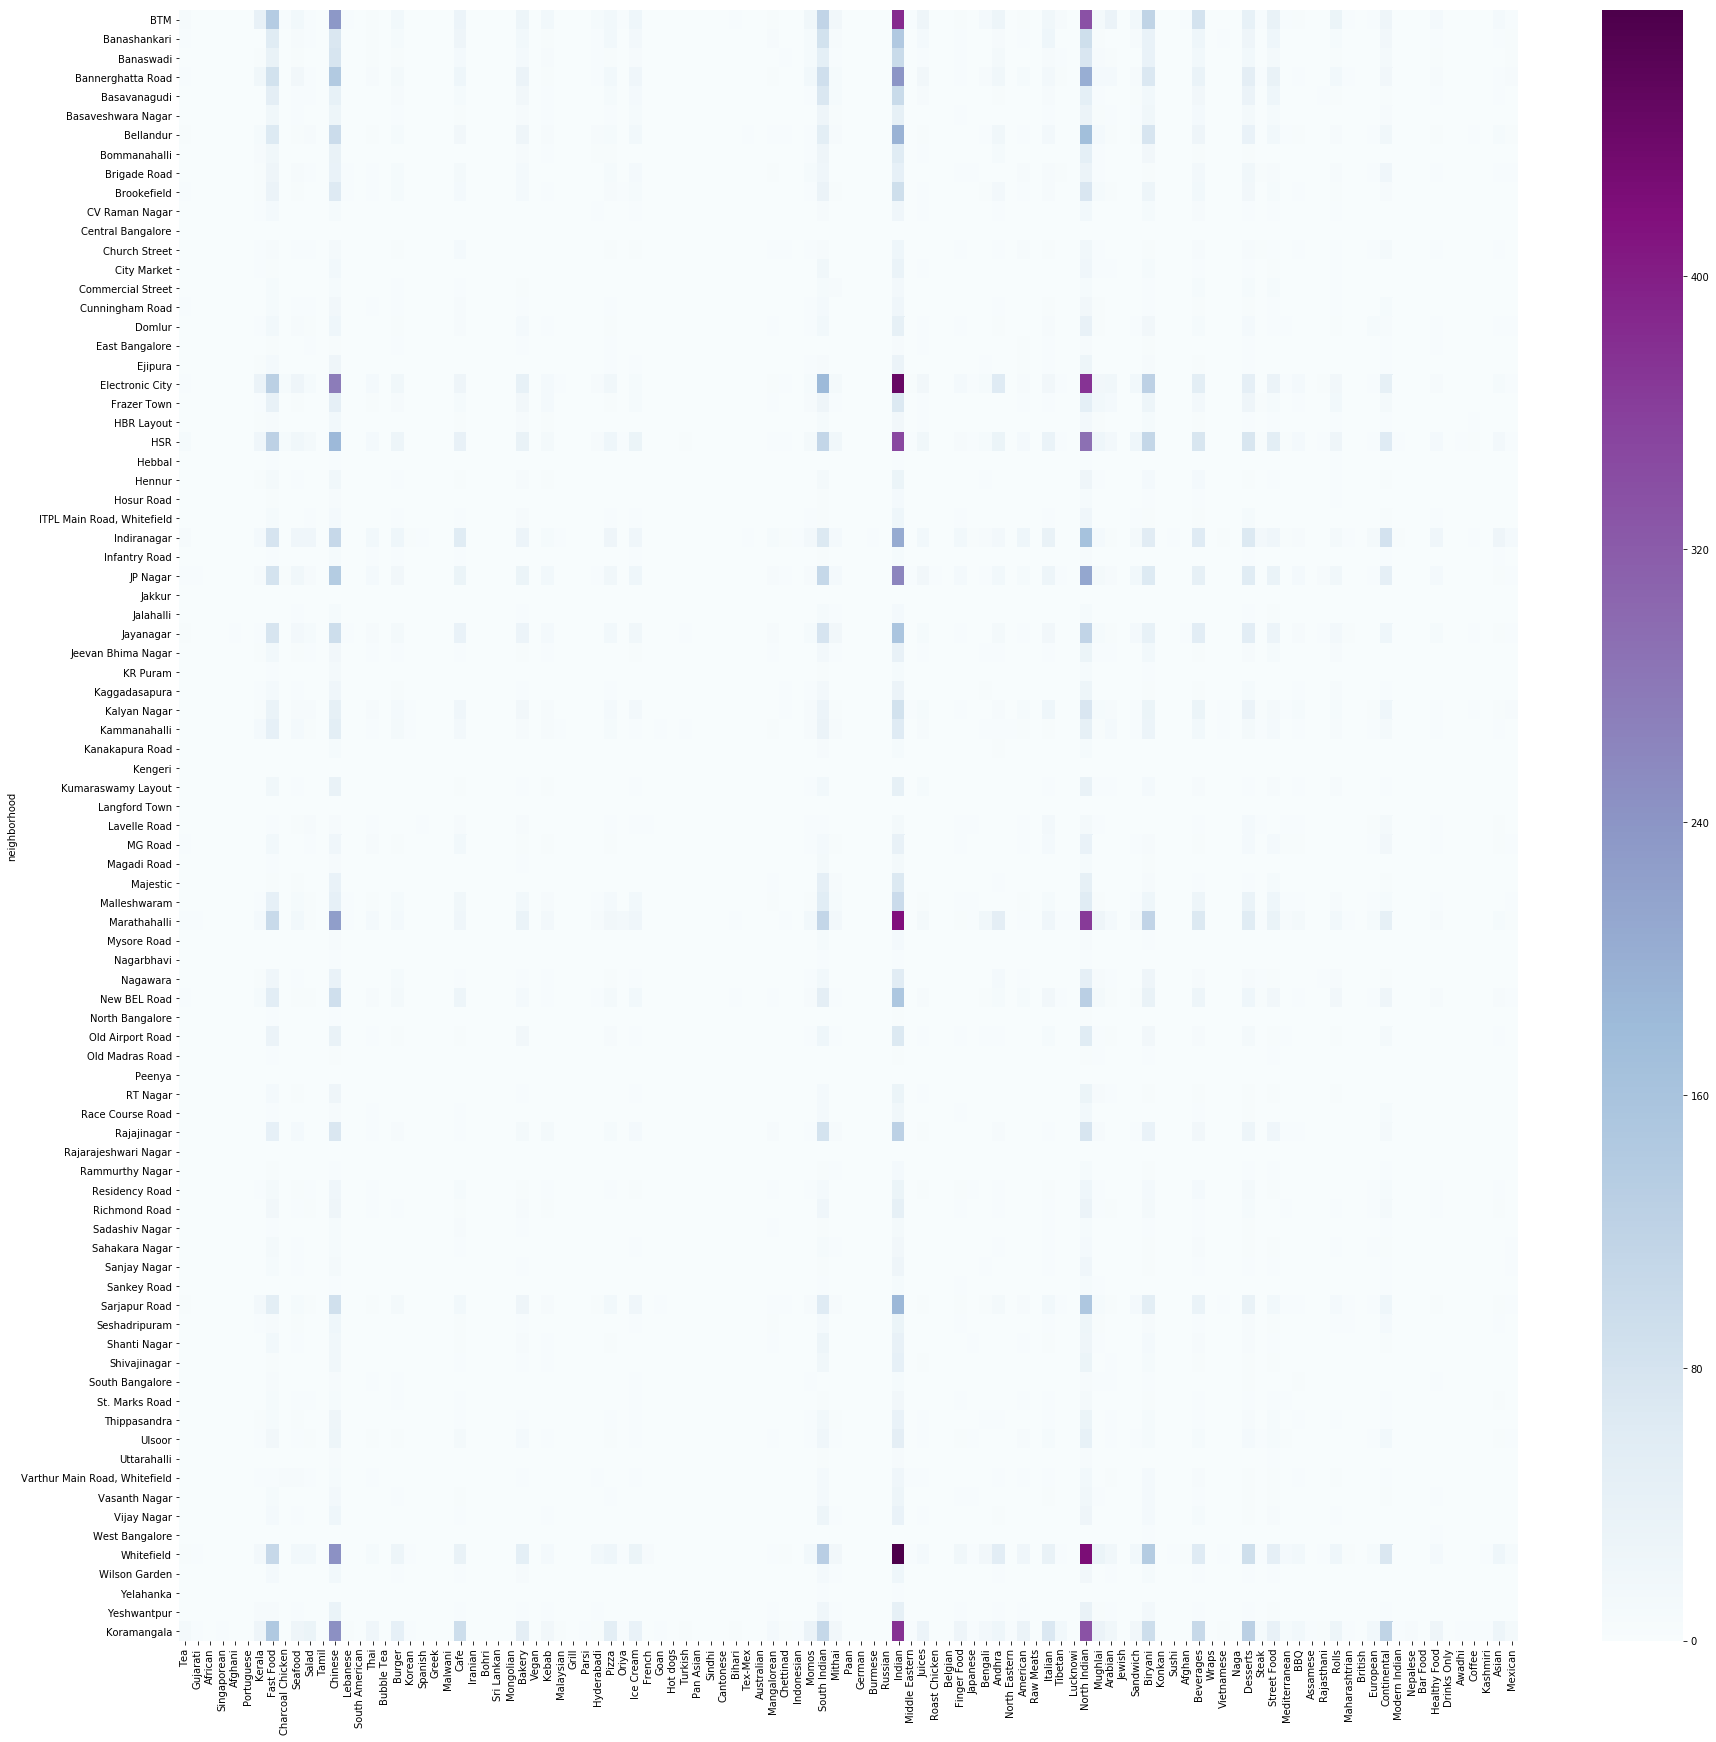

In [340]:
plt.figure(figsize=(30,30))
sns.heatmap(neighborhood_cns,cmap="BuPu")

So can we say, an area becomes more famous as a particular specififc type of cuisine/restaurant increases over there

#### Top 15 Cuisines Of Bengaluru

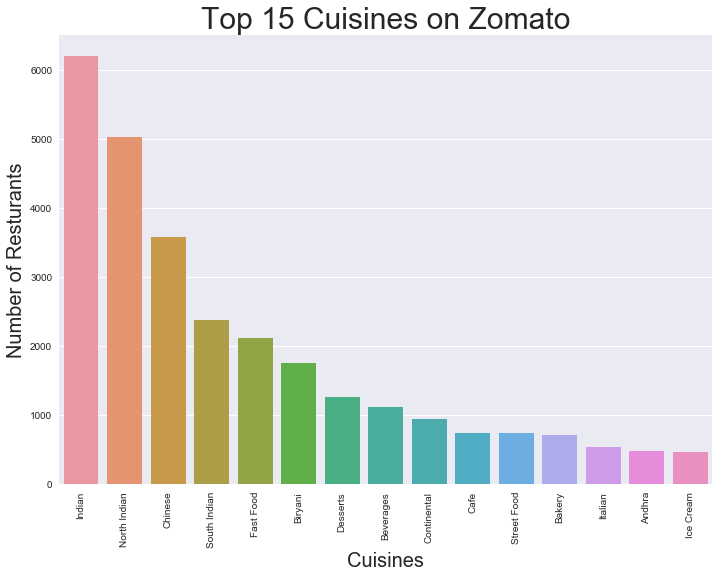

In [333]:

Cuisine_data = pd.DataFrame(neighborhood_cns.sum(axis=0))
Cuisine_data.reset_index(inplace=True)
Cuisine_data.columns = ['Cuisines', 'Number of Resturants']
Top15= (Cuisine_data.sort_values(['Number of Resturants'],ascending=False)).head(15)
sns.set(rc={'figure.figsize':(11.7,8.27)})
sns.barplot(Top15['Cuisines'], Top15['Number of Resturants'])
plt.xlabel('Cuisines', fontsize=20)
plt.ylabel('Number of Resturants', fontsize=20)
plt.title('Top 15 Cuisines on Zomato', fontsize=30)
plt.xticks(rotation = 90)
plt.show()

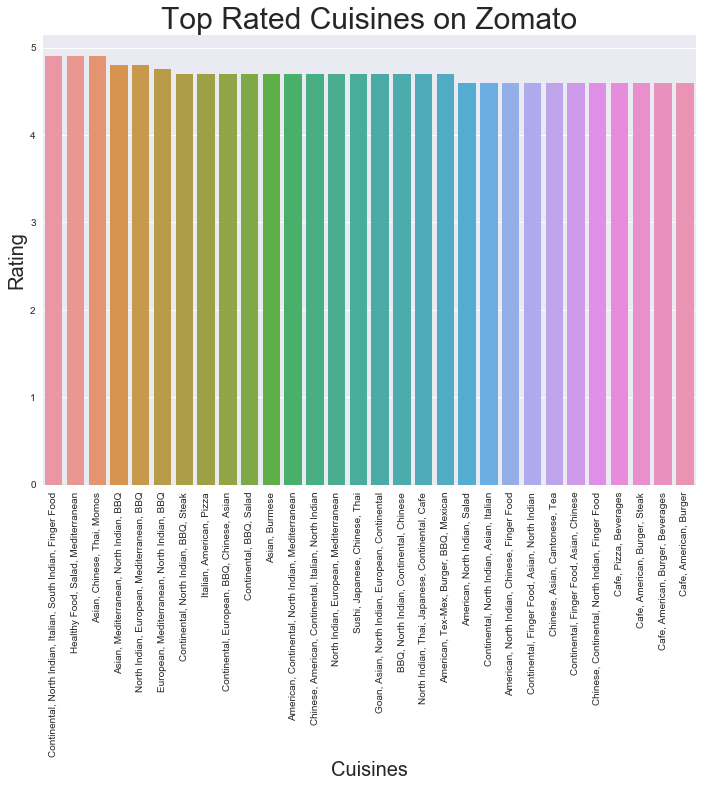

In [342]:
Cuisine_data_rating=(rest_df.groupby(['cuisines'], as_index=False)['rate'].mean())
Cuisine_data_rating.columns = ['Cuisines', 'Rating']
Top30_ratings= (Cuisine_data_rating.sort_values(['Rating'],ascending=False)).head(30)
sns.set(rc={'figure.figsize':(11.7,8.27)})
sns.barplot(Top30_ratings['Cuisines'], Top30_ratings['Rating'])
plt.title('Top Rated Cuisines on Zomato', fontsize=30)
plt.xlabel('Cuisines', fontsize=20)
plt.ylabel('Rating', fontsize=20)
plt.xticks(rotation = 90)
plt.show()

## Types Of Restaurant

In [240]:
listed = rest_df['listed_in(type)'].unique()
column_names = list(listed)
# instantiate the dataframe
neighborhood_lst = pd.DataFrame(columns=column_names)
neighborhood_lst

,Buffet,Cafes,Delivery,Desserts,Dine-out,Drinks & nightlife,Pubs and bars


In [241]:
neighborhood_lst['neighborhood'] = rest_df.groupby('location').groups.keys()
neighborhood_lst = neighborhood_lst.set_index('neighborhood').fillna(0)
neighborhood_lst

,Buffet,Cafes,Delivery,Desserts,Dine-out,Drinks & nightlife,Pubs and bars
neighborhood,,,,,,,
BTM,0,0,0,0,0,0,0
Banashankari,0,0,0,0,0,0,0
Banaswadi,0,0,0,0,0,0,0
Bannerghatta Road,0,0,0,0,0,0,0
Basavanagudi,0,0,0,0,0,0,0
Basaveshwara Nagar,0,0,0,0,0,0,0
Bellandur,0,0,0,0,0,0,0
Bommanahalli,0,0,0,0,0,0,0
Brigade Road,0,0,0,0,0,0,0


In [242]:
i=0
for i in range(0,len(rest_df)):
    for x in listed:
        if type(rest_df.loc[i, 'listed_in(type)']) == str and x in rest_df.loc[i, 'listed_in(type)'] and type(rest_df.loc[i, 'location']) == str:
            neighborhood_lst.loc[rest_df.loc[i, 'location'], x] = neighborhood_lst.loc[rest_df.loc[i, 'location'], x]+1

In [243]:
# Koramangala is divided into different block, lets combine them all
koramangala = ['Koramangala', 'Koramangala 1st Block', 'Koramangala 2nd Block', 'Koramangala 3rd Block', 'Koramangala 4th Block', 
'Koramangala 5th Block', 'Koramangala 6th Block', 'Koramangala 7th Block', 'Koramangala 8th Block']
koramangala_dict = dict(neighborhood_lst.loc[koramangala].sum())
neighborhood_lst = neighborhood_lst.drop(koramangala)
neighborhood_lst.loc['Koramangala'] = koramangala_dict

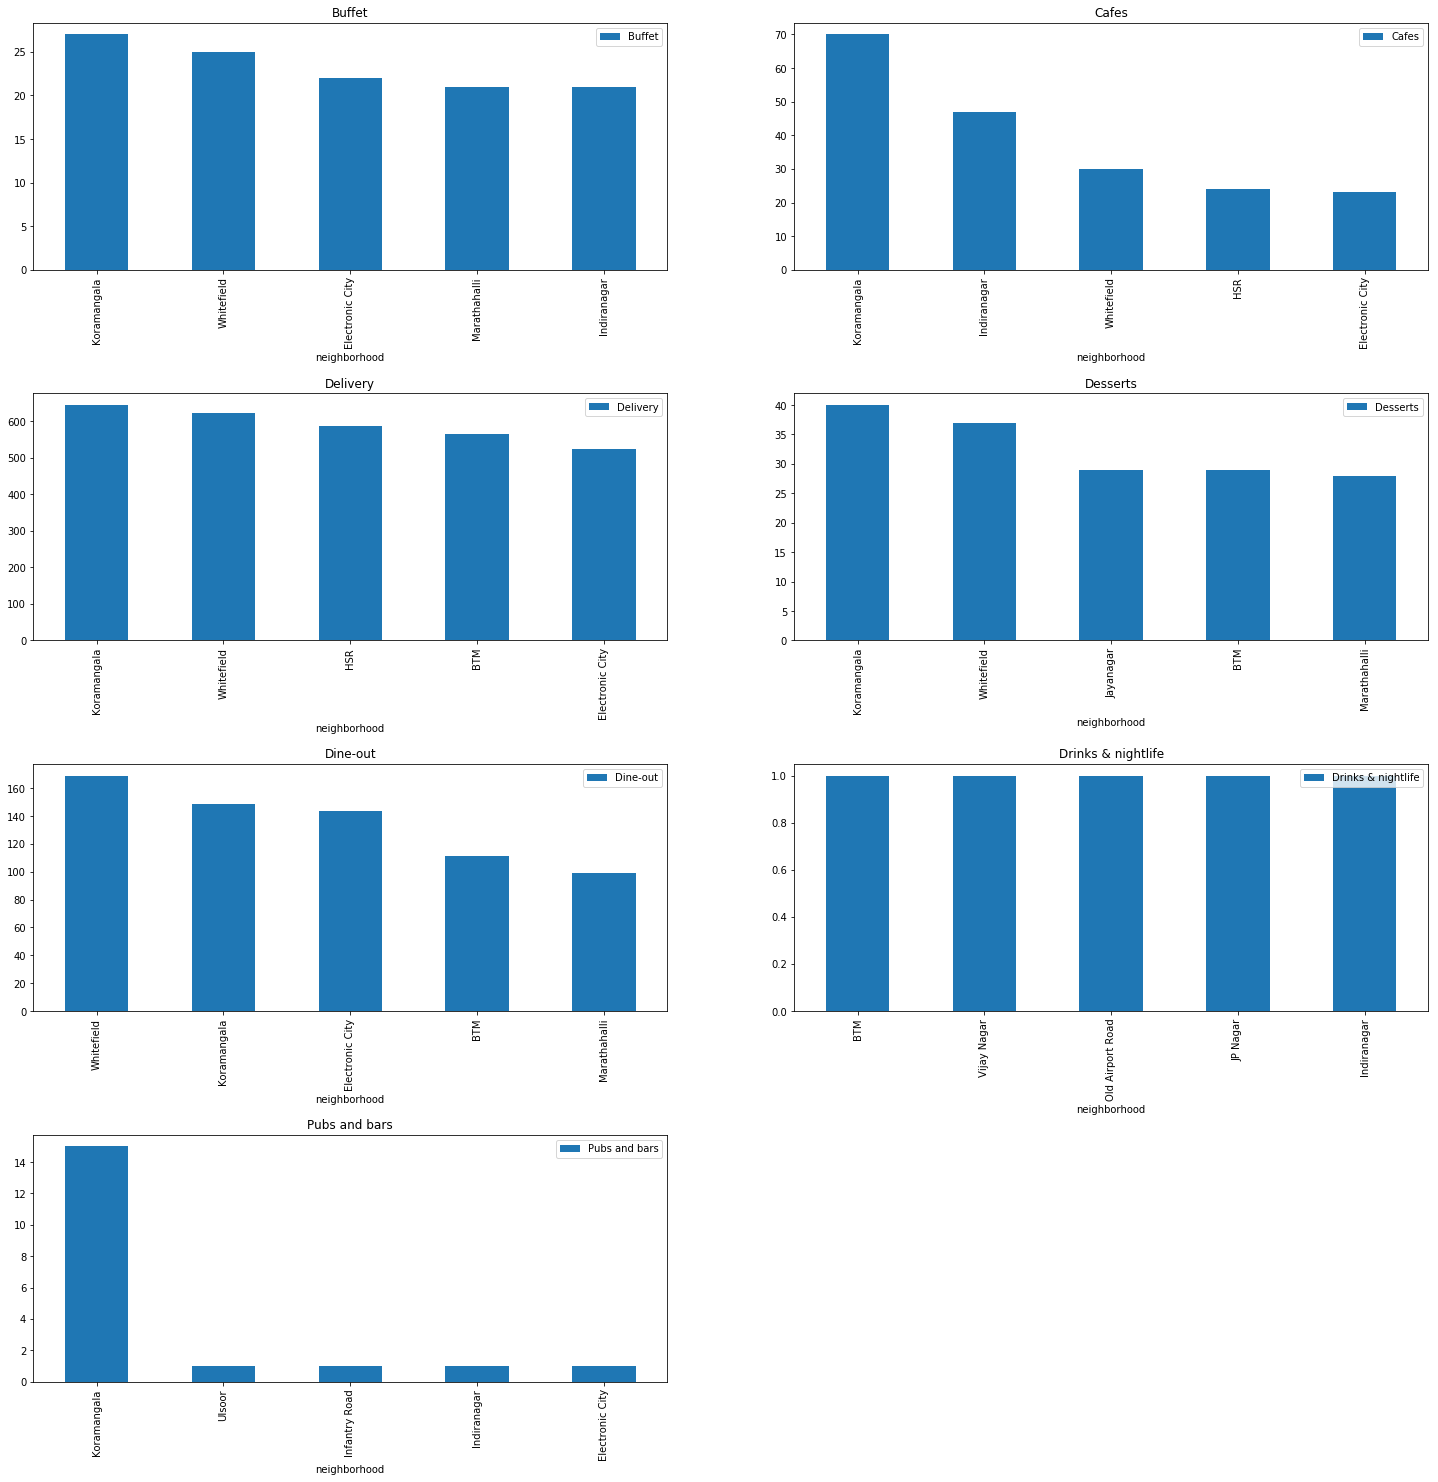

In [307]:
category = neighborhood_lst.columns
fig, ax = plt.subplots(nrows=4, ncols=2, figsize = (25,25))
fig.delaxes(ax[3,1])

plt.subplots_adjust(wspace=0.2, hspace=0.5)
ax = ax.flatten()

for i in range(0,len(category)):
    d= neighborhood_lst[[category[i]]].sort_values(by=category[i], ascending=False).head()
    d.plot(ax=ax[i],kind='bar')
    ax[i].set_title(category[i])
    ax[i].set_xticklabels(d.index, rotation='vertical')
    
plt.show()

Clearly Koramangala has most number of Pubs and bars, With whitefield having the most number of Dine out restaurant, Koramangala with high number of Desserts restaurant, again koramangala and whitefield with large number of delivery restaurant, Koramangala and Indira nagar with large number of Cafes and Koramangala and Whittefield with higher buffet restaurants than others.

It may not be wrong to conclude Koramangala as the hub of restaurants in Bengaluru.

## Rating

#### Restaurant rating Normal Distribution

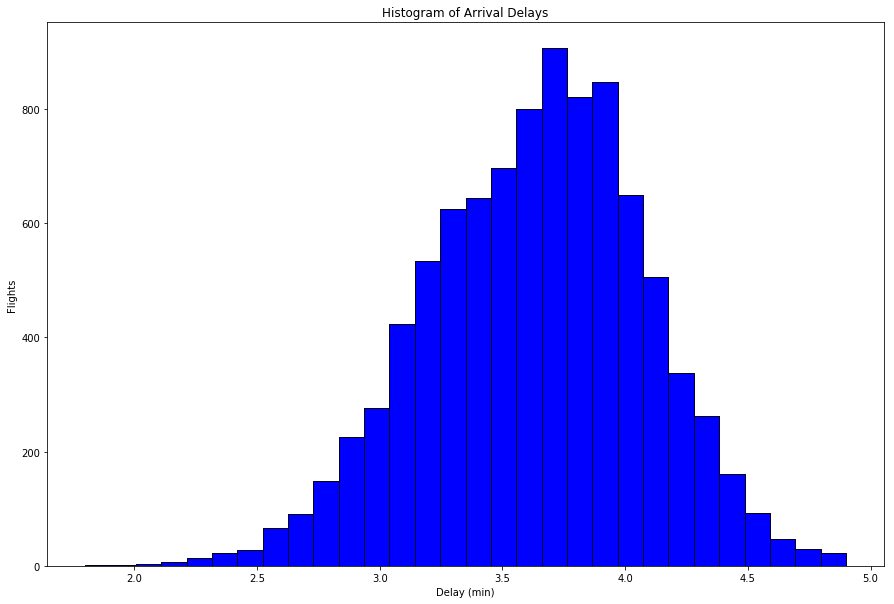

In [156]:
### Restaurant rating distibution
data = rest_df['rate'].dropna()
# matplotlib histogram
plt.figure(figsize=(15,10))
plt.hist(data, color = 'blue', edgecolor = 'black',
         bins = 30)

# seaborn histogram
sns.distplot(data, hist=True, kde=False 
             , color = 'blue',
             bins = 30,
             hist_kws={'edgecolor':'black'})
# Add labels
plt.title('Histogram of Arrival Delays')
plt.xlabel('Delay (min)')
plt.ylabel('Flights')

In general, the rating distribution is not normal but in the highest score 3.7 has peak! We have to carefully see the condition of the highest rated restuarant

In [162]:
rest_df[rest_df['rate'] >= 4.8]

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,...,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city),liked_food_from_review,menus_combined,location_latitude,location_longitude
1994,https://www.zomato.com/bangalore/brahmins-coff...,"Ranga Rao Road, Near Shankar Mutt, Shankarapur...",Brahmin's Coffee Bar,No,No,4.8,2679.0,+91 9845030234,Basavanagudi,Quick Bites,...,South Indian,100,"[('Rated 5.0', ""RATED\n Very soft idly, soft ...",[],Dine-out,Basavanagudi,"['idly vada', 'idly', 'single idli', 'kesari',...","['filter', 'coffee,', 'kesari', 'bath,', 'idli...",12.941726,77.575502
2087,https://www.zomato.com/bangalore/the-black-pea...,"20/7, Swamy Legato, Outer Ring Road, Kadubeesa...",The Black Pearl,No,Yes,4.8,7023.0,080 49653069,Marathahalli,"Casual Dining, Bar",...,"North Indian, European, Mediterranean, BBQ","1,500","[('Rated 5.0', 'RATED\n One of the best place...",[],Buffet,Bellandur,"['chai', 'apple', 'birthday treat', 'fish', 'o...","['dahipuri,', 'jal-jeera,', 'chicken', 'grill,...",12.955257,77.698416
2242,https://www.zomato.com/bangalore/byg-brewski-b...,"Behind MK Retail, Sarjapur Road, Bangalore",Byg Brewski Brewing Company,Yes,Yes,4.9,16345.0,+91 8039514766,Sarjapur Road,Microbrewery,...,"Continental, North Indian, Italian, South Indi...","1,600","[('Rated 5.0', 'RATED\n I have been to this p...",[],Delivery,Bellandur,"['mushroom', 'chai', 'fish', 'cutlet', 'lassi'...","['cocktails,', 'dahi', 'kebab,', 'rajma', 'cha...",12.924484,77.650272
3036,https://www.zomato.com/bangalore/belgian-waffl...,"65, Markham Road, Ashok Nagar, Brigade Road, B...",Belgian Waffle Factory,Yes,No,4.9,1746.0,+91 9481511911,Brigade Road,Dessert Parlor,...,Desserts,400,"[('Rated 3.0', ""RATED\n Waffles are totally w...",[],Delivery,Brigade Road,"['red velvet', 'belgian waffle', 'blueberry', ...","['coffee,', 'berryblast,', 'nachos,', 'chocola...",12.973613,77.607472
3917,https://www.zomato.com/bangalore/abs-absolute-...,"2nd Floor, I20-A2, EPIP Zone, Near Vydehi Hosp...",AB's - Absolute Barbecues,No,Yes,4.8,2882.0,040 45659913,Whitefield,Casual Dining,...,"European, Mediterranean, North Indian, BBQ","1,600","[('Rated 4.0', 'RATED\n Went today for Lunch ...",[],Buffet,Brookefield,"['mushroom', 'apple', 'bun', 'fish', 'rabri', ...","['mutton', 'roganjosh,', 'mutton', 'keema,', '...",12.969637,77.749745
3918,https://www.zomato.com/bangalore/flechazo-whit...,"120 A3, 2nd Floor, Santosh Tower, EPIP Industr...",Flechazo,No,Yes,4.9,2745.0,+91 8884333312,Whitefield,Casual Dining,...,"Asian, Mediterranean, North Indian, BBQ","1,400","[('Rated 5.0', 'RATED\n Food quality is amazi...",[],Buffet,Brookefield,"['wedges', 'make your own', 'mushroom', 'dates...","['pizza,', 'mutton', 'kebab,', 'chicken', 'bir...",12.969637,77.749745
4269,https://www.zomato.com/bangalore/punjab-grill-...,"Ground Floor, Forum Shantiniketan, Whitefield ...",Punjab Grill,Yes,No,4.9,518.0,+91 8448581880\r\n+91 8448581881,Whitefield,Casual Dining,...,North Indian,"2,000","[('Rated 5.0', 'RATED\n The food is great...t...","['Multani Paneer Tikka', 'Dal Punjab Grill', '...",Delivery,Brookefield,"['pista', 'mushroom', 'pista lassi', 'lassi', ...","['kadai', 'paneer,', 'kulfi,', 'kadhai', 'pane...",12.969637,77.749745
4906,https://www.zomato.com/bangalore/abs-absolute-...,"100 Feet Road, 1st Phase, Near Jayadeva Flyove...",AB's - Absolute Barbecues,No,Yes,4.9,6375.0,040 45659912,BTM,Casual Dining,...,"European, Mediterranean, North Indian, BBQ","1,600","[('Rated 5.0', 'RATED\n We liked the place a ...",[],Buffet,BTM,"['curd', 'mushroom', 'bun', 'fish', 'cheese', ...","['tangdi', 'chicken,', 'bbq', 'buffet,', 'choc...",12.911276,77.604565
4917,https://www.zomato.com/bangalore/asia-kitchen-...,"136, Ground Floor, 1st Cross, 5th Block, Jyoti...",Asia Kitchen By Mainland China,Yes,Yes,4.9,2178.0,080 49652573,Koramangala 5th Block,"Casual Dining, Bar",...,"Asian, Chinese, Thai, Momos","1,500","[('Rated 5.0', ""RATED\n

Most of the High rated restaurants had North Indian Cuisine in their menu, moreover we can see that all the higher rated restaurant has higher cost of food too. However location does not play much important role here.

### Price range and rating

In [237]:
# Now lets plot box plot based on the cost of food
bins = pd.IntervalIndex.from_tuples([(0, 500), (501, 1000), (1001, 2000), (2001, 3000), (3001, 4000), (4001, 5000), (5001, 6000)])
rest_df['cost_cat'] = pd.cut(rest_df['approx_cost(for two people)'], bins)


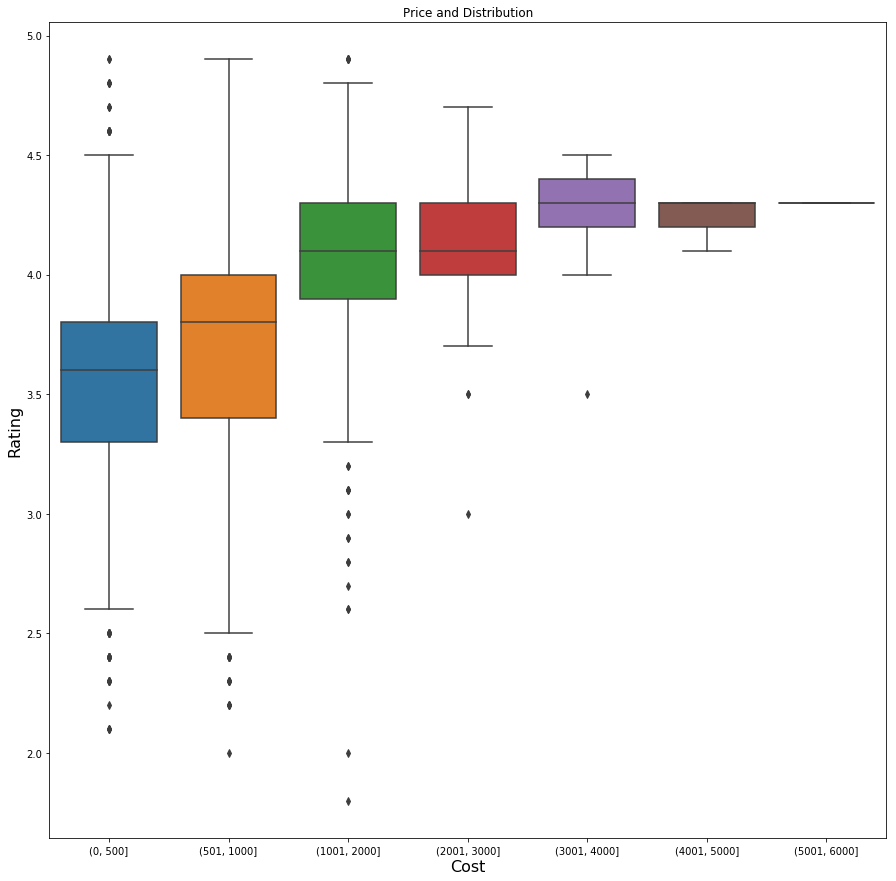

In [238]:
plt.figure(figsize=(15,15))
ax = sns.boxplot(x="cost_cat", y="rate", data=rest_df)
ax.set_xlabel('Cost', fontsize=16)
ax.set_ylabel('Rating', fontsize=16)
ax.set_title('Price and Distribution')
plt.savefig("box.png")
rest_df.drop('cost_cat', axis=1, inplace=True)

It can be seen that as the price increases the average rating of restaurants also increase. So can we say Price does affect rating of a restaurant.?
Not now, there may be some other factors too. lets find out

## Cuisine

#### Cuisine  and rating of a resaurant
Does having more number of cuisine mean higher rating of the restaurant

In [44]:
def fun(x):
    if(type(x) == list):
        return (len(x))
    else:
        return 0
rest_df['no_of_cuisine'] = rest_df['cuisines'].str.split(',').apply(fun)


In [49]:
rest_df.groupby(['no_of_cuisine'])['rate'].mean()

no_of_cuisine
0    3.400000
1    3.584998
2    3.589250
3    3.620158
4    3.736189
5    3.790373
6    3.917822
7    3.905357
8    3.768571
Name: rate, dtype: float64

In [52]:
rest_df.drop('no_of_cuisine', axis=1, inplace=True)

Yes it can be seen that retaurants having more number of cuisines are rated higher

#### So is there a particular cuisine in a restaurant that makes the restaurant rated higher

In [61]:
cuisine = set()
def func(x):
    if(type(x) == list):
        for y in x:
            cuisine.add(y.strip())
_ = rest_df['cuisines'].str.split(',').apply(func)

In [ ]:
cui_df = rest_df[['name', 'location', 'rate', 'cuisines']]
column_names = list(cuisine)
# instantiate the dataframe
cui_df = pd.concat([cui_df, pd.DataFrame(columns=column_names)], axis=1)
cui_df.loc[:, ~cui_df.columns.isin(['name', 'location', 'rate', 'cuisines'])] = cui_df.loc[:, ~cui_df.columns.isin(['name', 'location', 'rate', 'cuisines'])].fillna(0)
cui_df

In [84]:
for i in range(0, len(cui_df)):
    for x in cuisine:
        if type(cui_df.loc[i, 'cuisines']) == str and x in cui_df.loc[i, 'cuisines']:
            cui_df.loc[i, x] = cui_df.loc[i, x]+1

In [99]:
def set_pandas_options() -> None:
    pd.options.display.max_columns = 20
    pd.options.display.max_rows = 75
    pd.options.display.max_colwidth = 199
    pd.options.display.width = None
    # pd.options.display.precision = 2  # set as needed

set_pandas_options()

In [95]:
cui_df.groupby('rate').sum().tail(10).T

rate,4.0,4.1,4.2,4.3,4.4,4.5,4.6,4.7,4.8,4.9
Goan,1,2,2,0,1,0,0,1,0,0
Seafood,19,29,19,8,12,5,2,0,0,0
Korean,2,5,4,1,5,1,1,0,0,0
North Indian,225,178,110,78,63,31,13,14,5,5
African,0,0,0,1,0,0,2,0,0,0
Bakery,41,24,16,15,2,0,1,0,1,0
Chinese,162,117,65,41,34,17,10,5,0,1
Continental,79,91,76,58,39,26,8,11,3,1
Australian,0,0,0,0,0,0,0,0,0,0
Thai,24,15,11,11,11,7,2,2,0,1


After analysing the data it was found that these type of cuisines were very highly rated <i>Goa, Seafood, Korean, African,Fast Food, Biryani, Chinese, Continental, Thai, Sushi, Sindhi, Portuguese, Turkish, Naga, Jewish, 
Rajasthani, BBQ, Sandwich, Momos, Andhra, Steak, Tex-Mex, Arabian, Rolls, Healthy Food, Desserts, Finger Food, Pizza, Vietnamese
Italian, Mediterranean, Kebab, American, Japanese, Mexican, Indonesian, Burmese, European, French, Malaysian, Asian, Mughlai, Burger, 
Iranian</i> but among these <b>American, Italian, Pizza, Biryani, Continental, Chinese, Seafood, Korean</b> were much highly rated. Though North Indian, South Indian, Ice Cream, Mangalorean Beverages, Street Food, Cafe, Indian were the top rated but it is quite obvious for such type of restaurant to be at the top.

### Lets find out which neighborhood is famous for what type of cuisine

In [106]:
# Now can we say whcih neighborhood is famous for what type of food or cuisine
cuisine_grouped = cui_df.groupby('location').sum()
cuisine_grouped

,rate,Goan,Seafood,Korean,North Indian,African,Bakery,Chinese,Continental,Australian,...,Burger,Tamil,Tibetan,Middle Eastern,Nepalese,Assamese,Indian,Kashmiri,Roast Chicken,Iranian
location,,,,,,,,,,,,,,,,,,,,,
BTM,1842.5,0,16,0,335,0,27,236,25,0,...,15,0,6,2,1,0,385,1,0,0
Banashankari,823.1,0,6,1,93,0,15,71,18,0,...,9,0,1,0,0,0,144,0,0,1
Banaswadi,507.7,0,4,0,74,0,11,77,12,0,...,4,0,2,0,1,0,101,1,0,1
Bannerghatta Road,1216.6,0,18,0,200,1,33,143,18,0,...,13,0,5,1,0,0,239,0,0,0
Basavanagudi,650.5,0,3,0,50,0,18,42,5,0,...,6,0,0,0,0,0,101,0,0,0
Basaveshwara Nagar,240.9,0,3,0,32,0,6,27,6,0,...,2,0,0,0,0,0,45,0,0,0
Bellandur,904.8,0,4,0,172,0,26,98,20,1,...,9,1,0,0,0,0,194,1,1,1
Bommanahalli,173.8,0,1,0,50,0,7,39,1,0,...,1,0,0,0,0,0,61,0,0,0
Brigade Road,397.0,0,6,1,32,0,10,36,21,0,...,9,0,5,0,0,0,43,0,0,0


##### Lets print the top 5 cuisine famous in each of the neighborhood

In [140]:
num_top_venues = 5
for hood in cuisine_grouped.index:
    print("----"+hood+"----")
    temp = cuisine_grouped[cuisine_grouped.index == hood].T.reset_index()
    temp.columns = ['venue','freq']
    temp = temp.iloc[1:]
    temp['freq'] = temp['freq'].astype(float)
    temp = temp.round({'freq': 2})
    print(temp.sort_values('freq', ascending=False).reset_index(drop=True).head(num_top_venues))
    print('\n')

----BTM----
          venue   freq
0        Indian  385.0
1  North Indian  335.0
2       Chinese  236.0
3     Fast Food  138.0
4       Biryani  118.0


----Banashankari----
          venue   freq
0        Indian  144.0
1  North Indian   93.0
2  South Indian   85.0
3       Chinese   71.0
4     Fast Food   60.0


----Banaswadi----
          venue   freq
0        Indian  101.0
1       Chinese   77.0
2  North Indian   74.0
3  South Indian   49.0
4     Fast Food   38.0


----Bannerghatta Road----
          venue   freq
0        Indian  239.0
1  North Indian  200.0
2       Chinese  143.0
3  South Indian   91.0
4     Fast Food   85.0


----Basavanagudi----
          venue   freq
0        Indian  101.0
1  South Indian   72.0
2     Fast Food   52.0
3  North Indian   50.0
4       Chinese   42.0


----Basaveshwara Nagar----
          venue  freq
0        Indian  45.0
1  North Indian  32.0
2       Chinese  27.0
3  South Indian  25.0
4       Biryani  19.0


----Bellandur----
          venue   freq


4     Fast Food  16.0


----Magadi Road----
          venue  freq
0        Indian  13.0
1  South Indian  12.0
2  North Indian   8.0
3       Chinese   6.0
4       Biryani   5.0


----Majestic----
          venue  freq
0        Indian  68.0
1  South Indian  48.0
2  North Indian  45.0
3       Chinese  36.0
4   Street Food   9.0


----Malleshwaram----
          venue  freq
0        Indian  99.0
1  North Indian  60.0
2  South Indian  57.0
3       Chinese  43.0
4     Fast Food  43.0


----Marathahalli----
          venue   freq
0        Indian  417.0
1  North Indian  366.0
2       Chinese  226.0
3       Biryani  116.0
4  South Indian  113.0


----Mysore Road----
          venue  freq
0        Indian  11.0
1  South Indian   9.0
2  North Indian   7.0
3       Chinese   6.0
4       Biryani   3.0


----Nagarbhavi----
          venue  freq
0        Indian   3.0
1       Chinese   3.0
2  South Indian   3.0
3  North Indian   2.0
4   Street Food   1.0


----Nagawara----
          venue  freq
0        

#### Cuisine popular in Bengaluru

In [ ]:
from subprocess import check_output
from wordcloud import WordCloud
import matplotlib.pyplot as plt
wordcloud = (WordCloud(width=1440, height=1080, relative_scaling=0.5).generate_from_frequencies(cuisine_grouped.iloc[:,1:].sum()))

fig = plt.figure(1,figsize=(15, 15))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

<img src="https://i.ibb.co/kXXNq2S/cuisine.png" alt="wordcloud" height="1500" width="1500">

#### Rating and Cuisine
#### Is there any cuisine which is always rated high

In [156]:
cui_df
# Now lets plot box plot based on the cost of food
bins = pd.IntervalIndex.from_tuples([(0, 1), (1, 2), (2, 3), (3, 4), (4, 5)])
cui_df['rate_cat'] = pd.cut(cui_df['rate'], bins)
cui_df['rate_cat'] = cui_df['rate_cat'].astype(str)
cui_df['rate_cat'] = cui_df['rate_cat'].map({'(0.0, 1.0]' : 1, '(1.0, 2.0]' : 2, '(2.0, 3.0]' : 3, '(3.0, 4.0]' : 4, '(4.0, 5.0]' : 5 })

In [158]:
ra_cu = cui_df.groupby(['rate_cat']).sum()
ra_cu

,rate,Goan,Seafood,Korean,North Indian,African,Bakery,Chinese,Continental,Australian,...,Burger,Tamil,Tibetan,Middle Eastern,Nepalese,Assamese,Indian,Kashmiri,Roast Chicken,Iranian
rate_cat,,,,,,,,,,,,,,,,,,,,,
2.0,5.8,0,0,0,2,0,0,2,1,0,...,0,0,0,0,0,0,2,0,0,0
3.0,2489.5,0,23,0,482,0,37,394,35,0,...,30,0,6,1,0,0,526,0,0,0
4.0,24959.4,7,222,5,2870,0,397,2147,459,1,...,250,3,42,11,6,2,3471,7,9,3
5.0,6202.8,6,75,17,497,3,59,290,313,0,...,85,0,6,4,3,1,594,0,0,1


----2.0----
        cuisine  freq
0       Chinese   2.0
1  North Indian   2.0
2        Indian   2.0
3        Andhra   1.0
4  South Indian   1.0


----3.0----
        cuisine   freq
0        Indian  526.0
1  North Indian  482.0
2       Chinese  394.0
3     Fast Food  183.0
4       Biryani  155.0


----4.0----
        cuisine    freq
0        Indian  3471.0
1  North Indian  2870.0
2       Chinese  2147.0
3  South Indian  1323.0
4     Fast Food  1288.0


----5.0----
        cuisine   freq
0        Indian  594.0
1  North Indian  497.0
2   Continental  313.0
3       Chinese  290.0
4      Desserts  255.0




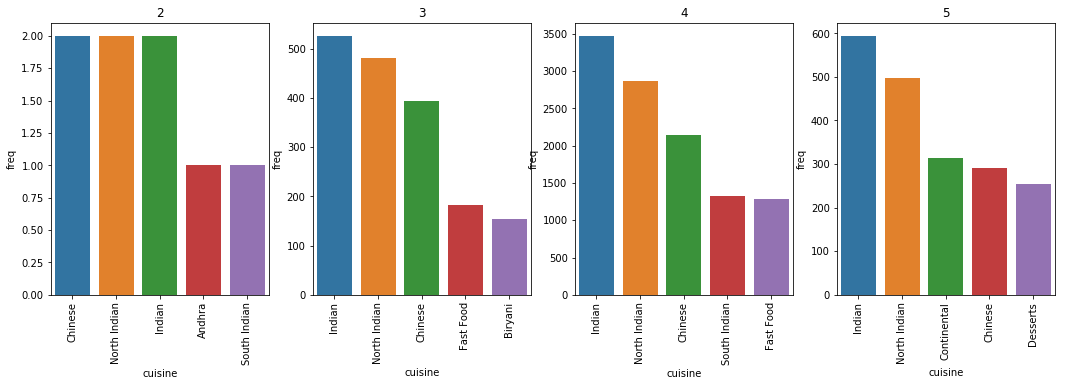

In [235]:
num_top_venues = 5
f, ax = plt.subplots(1,4, figsize = (18,5))
i = 2
for hood in ra_cu.index:
    print("----"+str(hood)+"----")
    temp = ra_cu[ra_cu.index == hood].T.reset_index()
    temp.columns = ['cuisine','freq']
    temp = temp.iloc[1:]
    temp['freq'] = temp['freq'].astype(float)
    temp = temp.round({'freq': 2})
    print(temp.sort_values('freq', ascending=False).reset_index(drop=True).head(num_top_venues))
    print('\n')
    sns.barplot(y = 'freq', x = 'cuisine', data = temp.sort_values('freq', ascending=False).reset_index(drop=True).head(num_top_venues), ax = ax[i-2],)
    ax[i-2].set_title(str(i))
    ax[i-2].set_xticklabels(temp.sort_values('freq', ascending=False).reset_index(drop=True).head(num_top_venues).cuisine, rotation='vertical')
    i+=1
plt.show()

Indian, North Indian, Chinese tough were common among the ratings but Most of the continental Cuisine restaurant were rated high which was also evident from the data, and not to forget there are large number of desserts restaurant

# Statistical Analysis

In [167]:
import statsmodels.formula.api as smf

### Are ratings affected by how cheap/expensive a restaurant is ?


In [233]:
data = [
    go.Scatter(x = rest_df['approx_cost(for two people)'],
              y = rest_df['rate'],
              mode = "markers",
               text = rest_df['name'],
               marker = dict(opacity = 0.7,
                            size = 10,
                            color = rest_df['rate'], #Set color equalivant to rating
                            colorscale= 'Viridis',
                            showscale=True,
                             maxdisplayed=2500,
                            ),
                hoverinfo="text+x+y",
              )
]
layout = go.Layout(autosize=True,
                   xaxis=dict(title="Average Cost of Two (INR)",
                             #titlefont=dict(size=20,),
                             #tickmode="linear",
                             ),
                   yaxis=dict(title="Rating",
                             #titlefont=dict(size=17,),
                             ),
                  )
iplot(dict(data=data, layout=layout))

As it seems, from a quick glance, there is no obseravable linear relationship. At almost every price point, there appears to be both Good and Bad restaurants.

Not wasting our time further lets carry out statistical analysis pearson correlation on it.<br>
<b>Null Hypothesis</b> : There is no relationship between the rating and price of the restaurant<br>
<b>Alternate Hypothesis</b> : There is some relationship between the two


In [375]:
pear = rest_df.dropna(subset=['approx_cost(for two people)', 'rate'])

In [379]:
from scipy import stats 
pearson_coef, p_value = stats.pearsonr(pear['approx_cost(for two people)'], pear['rate']) 
print("Pearson Correlation Coefficient: ", pearson_coef, "and a P-value of:", p_value) # Results 

Pearson Correlation Coefficient:  0.32609607011051456 and a P-value of: 3.595009214519809e-228


The p-values comes out to be much much lower than our signifiance level. Hence we reject our NULL hypothesis and accept the alternate hypothesis. And our finding can be said to be statistically significant.
Therefore we can say that there is some relationship between the two.

### Do more votes == Higher Ratings?

c:\users\himanshu poddar\appdata\local\programs\python\python36-32\lib\site-packages\scipy\stats\stats.py:1706: FutureWarning:

Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.



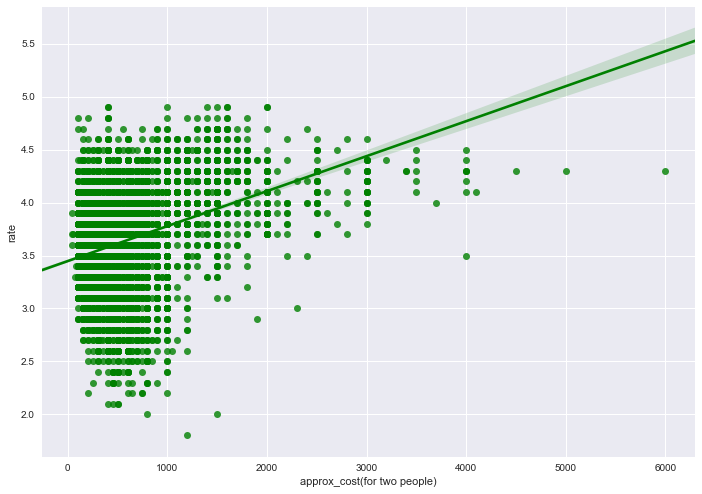

In [388]:
ax = sns.regplot(x=pear['approx_cost(for two people)'], y=pear['rate'], color="g")

As it seems, from a quick glance, there is no obseravable linear relationship. At almost every price point, there appears to be both low and high cost restaurants.

Lets carry out the statistical analysis

<b>Null Hypothesis</b> : There is no relationship between the rating and votes of the restaurant<br>
<b>Alternate Hypothesis</b> : There is some relationship between the two


In [383]:
pear = rest_df.dropna(subset=['votes', 'rate'])

In [384]:
pearson_coef, p_value = stats.pearsonr(pear['votes'], pear['rate']) 
print("Pearson Correlation Coefficient: ", pearson_coef, "and a P-value of:", p_value) # Results 

Pearson Correlation Coefficient:  0.39935415986250994 and a P-value of: 0.0


The p-value shows result is significant. And hence we reject our NULL hypothesis and accept the Alternate Hypothesis i.e both the variables are related and our finding was statistically significant

### Are restaurants that offer Table booking option rated higher?

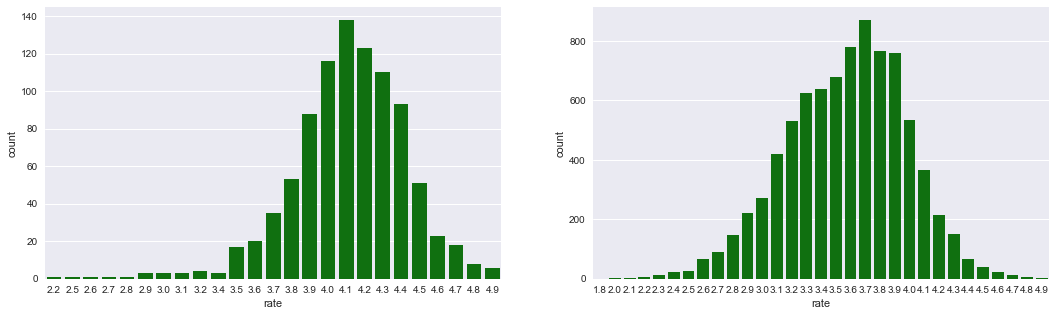

In [420]:
pear = rest_df[rest_df['book_table'] == 'Yes']
f, ax = plt.subplots(1,2, figsize = (18,5))
sns.countplot(pear['rate'], color="g", ax=ax[0])
pear = rest_df[rest_df['book_table'] == 'No']
sns.countplot(pear['rate'], color="g",  ax=ax[1])
plt.show()

In [424]:
model = smf.ols(formula='rate ~ C(book_table)', data=rest_df).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                   rate   R-squared:                       0.141
Model:                            OLS   Adj. R-squared:                  0.141
Method:                 Least Squares   F-statistic:                     1526.
Date:                Mon, 22 Apr 2019   Prob (F-statistic):          3.39e-309
Time:                        20:59:06   Log-Likelihood:                -4663.8
No. Observations:                9285   AIC:                             9332.
Df Residuals:                    9283   BIC:                             9346.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                3.5712 

Yes, The relation is statistically significant

## Now Lets see the top venues of each areas of Bangalore 
These are venues with the highest foot traffic at the time this regular call to the API is made. So at what time restaurants are more famous

In [4]:
import requests
from pandas.io.json import json_normalize

In [5]:
CLIENT_ID = 'WPTSXRBGDLUULN1OWDRCQUAE3KIEDUNMQM5AW5Q0DH5UCCAY' # your Foursquare ID
CLIENT_SECRET = 'TR4030IUWOWEHNIZCT0EQGVC2BMLZV35KSHH404AAWSMFXAU' # your Foursquare Secret
VERSION = '20180604'
LIMIT = 100
radius = 9999

In [6]:
# function that extracts the category of the venue
def get_category_type(row):
    try:
        categories_list = row['categories']
    except:
        categories_list = row['venue.categories']
        
    if len(categories_list) == 0:
        return None
    else:
        return categories_list[0]['name']

In [25]:
neigh_lat_lon = rest_df.groupby(['location'])['location_latitude', 'location_longitude'].first()
neigh_lat_lon

,location_latitude,location_longitude
location,,
BTM,12.911276,77.604565
Banashankari,12.915382,77.573638
Banaswadi,13.014162,77.651854
Bannerghatta Road,12.920579,77.600117
Basavanagudi,12.941726,77.575502
Basaveshwara Nagar,12.993224,77.539158
Bellandur,12.979120,77.591300
Bommanahalli,12.908945,77.623904
Brigade Road,12.973613,77.607472


In [52]:
column_names = ['cat1', 'cat2', 'cat3', 'cat4', 'cat5']
# instantiate the dataframe
df = pd.DataFrame(columns=column_names)
df

,cat1,cat2,cat3,cat4,cat5


In [ ]:
i=0
for lat, long in zip(neigh_lat_lon.location_latitude, neigh_lat_lon.location_longitude):
    latitude = lat
    longitude = long
    # define URL
    url = 'https://api.foursquare.com/v2/venues/explore?client_id={}&client_secret={}&ll={},{}&v={}&radius={}&limit={}'.format(CLIENT_ID, CLIENT_SECRET, latitude, longitude, VERSION, radius, LIMIT)
    # send GET request and get trending venues
    results = requests.get(url).json()
    items = results['response']['groups'][0]['items']
    
    dataframe = json_normalize(items) # flatten JSON

    # filter columns
    filtered_columns = ['venue.name', 'venue.categories'] + [col for col in dataframe.columns if col.startswith('venue.location.')] + ['venue.id']
    dataframe_filtered = dataframe.loc[:, filtered_columns]

    # filter the category for each row
    dataframe_filtered['venue.categories'] = dataframe_filtered.apply(get_category_type, axis=1)

    # clean columns
    dataframe_filtered.columns = [col.split('.')[-1] for col in dataframe_filtered.columns]

    print(neigh_lat_lon.index[i], " : ",dataframe_filtered.head(5)['categories'])
    df.loc[neigh_lat_lon.index[i]] = dataframe_filtered.head(5)['categories'].tolist()
    i+=1
    

In [57]:
df

,cat1,cat2,cat3,cat4,cat5
BTM,Ice Cream Shop,Snack Place,Indian Restaurant,Performing Arts Venue,Burger Joint
Banashankari,Pizza Place,Performing Arts Venue,Snack Place,Sandwich Place,Ice Cream Shop
Banaswadi,Ice Cream Shop,Bakery,Ice Cream Shop,Falafel Restaurant,Brewery
Bannerghatta Road,Indian Restaurant,Ice Cream Shop,Burger Joint,Performing Arts Venue,Snack Place
Basavanagudi,Indian Restaurant,Dessert Shop,Sandwich Place,Indian Restaurant,Breakfast Spot
Basaveshwara Nagar,Ice Cream Shop,Bakery,Bakery,Shopping Mall,Hotel
Bellandur,Park,Shopping Mall,Hotel,Hotel,Tea Room
Bommanahalli,Burger Joint,Mobile Phone Shop,BBQ Joint,Ice Cream Shop,Italian Restaurant
Brigade Road,Brewery,American Restaurant,Burger Joint,Lounge,Cocktail Bar
Brookefield,Ice Cream Shop,Indian Restaurant,Brewery,Office,Creperie


# Cluster Neighborhoods

### Clustering on the basis of cuisine

In [169]:
## Now lets use ML to cluster neighborhoods by their food style
# import k-means from clustering stage
from sklearn.cluster import KMeans

In [190]:
cuisine = set()
def func(x):
    if(type(x) == list):
        for y in x:
            cuisine.add(y.strip())
_ = rest_df['cuisines'].str.split(',').apply(func)
cui_df = rest_df[['name', 'location', 'rate', 'cuisines']]
column_names = list(cuisine)
# instantiate the dataframe
cui_df = pd.concat([cui_df, pd.DataFrame(columns=column_names)], axis=1)
cui_df.loc[:, ~cui_df.columns.isin(['name', 'location', 'rate', 'cuisines'])] = cui_df.loc[:, ~cui_df.columns.isin(['name', 'location', 'rate', 'cuisines'])].fillna(0)
cui_df

,name,location,rate,cuisines,South American,Awadhi,Jewish,Hot dogs,Continental,Mithai,...,Modern Indian,Sri Lankan,Charcoal Chicken,Italian,Indonesian,Healthy Food,Raw Meats,Steak,Kebab,Kerala
0,Jalsa,Banashankari,4.1,"North Indian, Mughlai, Chinese",0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Spice Elephant,Banashankari,4.1,"Chinese, North Indian, Thai",0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,San Churro Cafe,Banashankari,3.8,"Cafe, Mexican, Italian",0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Addhuri Udupi Bhojana,Banashankari,3.7,"South Indian, North Indian",0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Grand Village,Basavanagudi,3.8,"North Indian, Rajasthani",0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,Timepass Dinner,Basavanagudi,3.8,North Indian,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,Rosewood International Hotel - Bar & Restaurant,Mysore Road,3.6,"North Indian, South Indian, Andhra, Chinese",0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,Onesta,Banashankari,4.6,"Pizza, Cafe, Italian",0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,Penthouse Cafe,Banashankari,4.0,"Cafe, Italian, Continental",0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,Smacznego,Banashankari,4.2,"Cafe, Mexican, Italian, Momos, Beverages",0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [195]:
for i in range(0, len(cui_df)):
    for x in cuisine:
        if type(cui_df.loc[i, 'cuisines']) == str and x in cui_df.loc[i, 'cuisines']:
            cui_df.loc[i, x] = cui_df.loc[i, x]+1

cuisine_grouped = cui_df.groupby('location').sum()
cuisine_grouped.drop('name', axis=1, inplace=True)
cuisine_grouped

,South American,Awadhi,Jewish,Hot dogs,Continental,Mithai,Cantonese,Pizza,Mangalorean,Konkan,...,Modern Indian,Sri Lankan,Charcoal Chicken,Italian,Indonesian,Healthy Food,Raw Meats,Steak,Kebab,Kerala
location,,,,,,,,,,,,,,,,,,,,,
BTM,0,0,0,0,25,17,0,16,4,0,...,0,0,3,19,0,10,0,2,15,41
Banashankari,0,0,0,0,18,7,0,15,7,0,...,0,0,0,24,1,2,0,1,5,0
Banaswadi,0,0,0,0,12,3,0,4,1,0,...,1,0,0,6,0,4,0,0,6,4
Bannerghatta Road,0,0,0,0,18,9,0,15,4,0,...,0,0,0,14,0,7,0,2,4,19
Basavanagudi,0,0,0,0,5,8,0,9,1,0,...,0,0,0,6,0,3,0,0,3,0
Basaveshwara Nagar,0,0,0,0,6,5,0,2,1,0,...,0,0,0,3,0,0,0,0,3,0
Bellandur,0,0,0,0,20,6,0,9,2,0,...,1,0,0,14,0,5,0,1,7,8
Bommanahalli,0,0,0,0,1,1,0,4,0,0,...,0,0,0,1,0,1,0,0,2,6
Brigade Road,0,0,0,0,21,1,0,8,4,1,...,0,0,0,7,0,2,0,4,0,5


In [194]:
# Koramangala is divided into different block, lets combine them all
koramangala = ['Koramangala', 'Koramangala 1st Block', 'Koramangala 2nd Block', 'Koramangala 3rd Block', 'Koramangala 4th Block', 
'Koramangala 5th Block', 'Koramangala 6th Block', 'Koramangala 7th Block', 'Koramangala 8th Block']
koramangala_dict = dict(cuisine_grouped.loc[koramangala].sum())
cuisine_grouped = cuisine_grouped.drop(koramangala)
cuisine_grouped.loc['Koramangala'] = koramangala_dict

,name,South American,Awadhi,Jewish,Hot dogs,Continental,Mithai,Cantonese,Pizza,Mangalorean,...,Modern Indian,Sri Lankan,Charcoal Chicken,Italian,Indonesian,Healthy Food,Raw Meats,Steak,Kebab,Kerala
location,,,,,,,,,,,,,,,,,,,,,
BTM,Sankranthi Veg RestaurantHearts Unlock Cafeeat...,0,0,0,0,25,17,0,16,4,...,0,0,3,19,0,10,0,2,15,41
Banashankari,JalsaSpice ElephantSan Churro CafeAddhuri Udup...,0,0,0,0,18,7,0,15,7,...,0,0,0,24,1,2,0,1,5,0
Banaswadi,Cafe NibrasThe SanctuaryCrunch Pizzas9 BowlsPi...,0,0,0,0,12,3,0,4,1,...,1,0,0,6,0,4,0,0,6,4
Bannerghatta Road,Deja Vu Resto BarFattoushEmpire RestaurantAbhi...,0,0,0,0,18,9,0,15,4,...,0,0,0,14,0,7,0,2,4,19
Basavanagudi,Grand VillageTimepass DinnerSrinathji's CafeRe...,0,0,0,0,5,8,0,9,1,...,0,0,0,6,0,3,0,0,3,0
Basaveshwara Nagar,OnestaSlanz CafeHalli Donne Biryani Nati Style...,0,0,0,0,6,5,0,2,1,...,0,0,0,3,0,0,0,0,3,0
Bellandur,Kava - Fairfield by MarriottMoMo Cafe - Courty...,0,0,0,0,20,6,0,9,2,...,1,0,0,14,0,5,0,1,7,8
Bommanahalli,Pizza PalaceIndian Desi MomoGruhalakshmi Home ...,0,0,0,0,1,1,0,4,0,...,0,0,0,1,0,1,0,0,2,6
Brigade Road,Kitchen On TablePanchavati Gaurav ThaliSaatvik...,0,0,0,0,21,1,0,8,4,...,0,0,0,7,0,2,0,4,0,5


In [196]:
# set number of clusters
kclusters = 3

bangalore_grouped_clustering = cuisine_grouped

# run k-means clustering
kmeans = KMeans(n_clusters=kclusters, random_state=0).fit(bangalore_grouped_clustering)

# check cluster labels generated for each row in the dataframe
kmeans.labels_

array([1, 2, 0, 2, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 2, 0, 2, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0,
       0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1])

In [197]:
cuisine_grouped.insert(0, 'Cluster Labels', kmeans.labels_)

In [198]:
cuisine_grouped.groupby('Cluster Labels').get_group(0)

,Cluster Labels,South American,Awadhi,Jewish,Hot dogs,Continental,Mithai,Cantonese,Pizza,Mangalorean,...,Modern Indian,Sri Lankan,Charcoal Chicken,Italian,Indonesian,Healthy Food,Raw Meats,Steak,Kebab,Kerala
location,,,,,,,,,,,,,,,,,,,,,
Banaswadi,0,0,0,0,0,12,3,0,4,1,...,1,0,0,6,0,4,0,0,6,4
Basavanagudi,0,0,0,0,0,5,8,0,9,1,...,0,0,0,6,0,3,0,0,3,0
Basaveshwara Nagar,0,0,0,0,0,6,5,0,2,1,...,0,0,0,3,0,0,0,0,3,0
Bommanahalli,0,0,0,0,0,1,1,0,4,0,...,0,0,0,1,0,1,0,0,2,6
Brigade Road,0,0,0,0,0,21,1,0,8,4,...,0,0,0,7,0,2,0,4,0,5
Brookefield,0,0,0,0,0,7,5,0,6,0,...,0,0,0,6,0,1,0,0,3,4
CV Raman Nagar,0,0,0,0,0,0,1,0,1,0,...,0,0,0,0,0,1,0,0,0,2
Central Bangalore,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Church Street,0,0,0,0,0,13,0,0,4,2,...,0,0,0,5,0,2,0,4,1,2


In [199]:
cuisine_grouped.groupby('Cluster Labels').get_group(1)

,Cluster Labels,South American,Awadhi,Jewish,Hot dogs,Continental,Mithai,Cantonese,Pizza,Mangalorean,...,Modern Indian,Sri Lankan,Charcoal Chicken,Italian,Indonesian,Healthy Food,Raw Meats,Steak,Kebab,Kerala
location,,,,,,,,,,,,,,,,,,,,,
BTM,1,0,0,0,0,25,17,0,16,4,...,0,0,3,19,0,10,0,2,15,41
Electronic City,1,0,0,0,0,46,12,0,19,4,...,0,0,8,18,0,7,0,0,10,33
HSR,1,0,2,0,0,62,19,0,24,2,...,2,0,8,35,0,11,0,4,12,22
Marathahalli,1,0,0,0,1,45,14,0,17,0,...,1,0,0,22,0,7,0,3,14,11
Whitefield,1,0,0,0,0,71,17,0,23,2,...,1,0,1,39,1,11,0,2,11,14
Koramangala,1,0,2,0,0,119,17,0,54,11,...,3,1,0,70,2,26,0,9,18,25


In [200]:
cuisine_grouped.groupby('Cluster Labels').get_group(2)

,Cluster Labels,South American,Awadhi,Jewish,Hot dogs,Continental,Mithai,Cantonese,Pizza,Mangalorean,...,Modern Indian,Sri Lankan,Charcoal Chicken,Italian,Indonesian,Healthy Food,Raw Meats,Steak,Kebab,Kerala
location,,,,,,,,,,,,,,,,,,,,,
Banashankari,2,0,0,0,0,18,7,0,15,7,...,0,0,0,24,1,2,0,1,5,0
Bannerghatta Road,2,0,0,0,0,18,9,0,15,4,...,0,0,0,14,0,7,0,2,4,19
Bellandur,2,0,0,0,0,20,6,0,9,2,...,1,0,0,14,0,5,0,1,7,8
Indiranagar,2,0,0,0,1,83,10,0,26,8,...,5,1,0,39,3,22,0,14,9,10
JP Nagar,2,1,1,0,0,48,11,0,20,6,...,0,0,5,27,0,10,0,1,16,7
Jayanagar,2,0,0,0,0,24,17,0,15,7,...,0,0,1,17,0,9,0,0,10,2
New BEL Road,2,0,0,0,0,25,3,0,12,2,...,0,0,1,17,0,6,0,4,3,8
Rajajinagar,2,0,0,0,0,12,7,0,8,7,...,0,0,0,3,0,1,0,0,12,0
Sarjapur Road,2,0,0,0,0,24,6,0,16,2,...,0,0,1,15,0,4,0,0,7,14


<!-- -->

#### Lets see them on map

In [201]:
map_df = pd.merge(rest_df[['location','location_latitude', 'location_longitude']].groupby('location').first(), cuisine_grouped, left_index=True, right_index=True)

In [234]:
venues_map = folium.Map(location=[12.934533, 77.626579], zoom_start=11) # generate map centred around Bengaluru

states = folium.map.FeatureGroup()
labels = set(kmeans.labels_)
venues_map = folium.Map(location=[12.934533, 77.626579], zoom_start=11) # generate map centred around Bengaluru

states = folium.map.FeatureGroup()
i=0
j=0
for label in labels:
    group = map_df.groupby('Cluster Labels').get_group(label)
    for lat, lng, in zip(group.location_latitude, group.location_longitude):
        states.add_child(
            folium.features.CircleMarker(
                [lat, lng],
                radius=5, # define how big you want the circle markers to be
                color='yellow',
                fill=True,
                fill_color='blue',
                fill_opacity=0.6,
            )
        )
        i+=1
    colors = ['blue', 'green', 'purple']
    
    x = group.index
    i=0
    for lat, lng, in zip(group.location_latitude, group.location_longitude):
        states.add_child(
            folium.features.Marker(
                [lat, lng],
                popup= group.index[i],
                icon=folium.Icon(color=colors[j], icon='cloud')
            )
        )
        i+=1
    j+=1
# add incidents to map
venues_map.add_child(states)



venues_map

On analysing the data it was found that North Indian, Indian, South Indian are available and famous in most(approx 90%) of the neighborhood of Bengaluru. But among them the key observation were. 
Cluster 0 or those marked in Red are the places that are more famous for its foreign cuisines can be goan, assamese, bihari, american, thai etc.<br>

<b>Cluster 1</b> or those marked in Blue are the places that are more famous for its Biryani, Chinese, Fast food and North Indian food.
<br>
<b>Cluster 2</b> or those marked in Green are those places that are more famous for its South Indian, Indian, North Indian, Chinese as well as fast food.<br>
<b>Cluster 3</b> or those marked in Purple were those areas where Street Food, Chinese, Fast food were more popular or we can say more number of restaurants were present.

### Clustering on the basis of type of restaurants

In [11]:
types = set()
def func(x):
    if(type(x) == list):
        for y in x:
            types.add(y.strip())
_ = rest_df['rest_type'].str.split(',').apply(func)
column_names = list(types)
# instantiate the dataframe

In [ ]:
neighborhood = pd.DataFrame(columns=column_names)
neighborhood
neighborhood['neighborhood'] = rest_df.groupby('location').groups.keys()
neighborhood = neighborhood.set_index('neighborhood').fillna(0)
neighborhood
i=0
for i in range(0,len(rest_df)):
    for x in types:
        if type(rest_df.loc[i, 'rest_type']) == str and x in rest_df.loc[i, 'rest_type']:
            neighborhood.loc[rest_df.loc[i, 'location'], x] = neighborhood.loc[rest_df.loc[i, 'location'], x]+1

In [204]:
neighborhood

,Cluster Labels,Food Court,Club,Food Truck,Bakery,Lounge,Bhojanalya,Dessert Parlor,Confectionery,Dhaba,...,Casual Dining,Beverage Shop,Pub,Sweet Shop,Delivery,Fine Dining,Pop Up,Bar,Irani Cafee,Cafe
neighborhood,,,,,,,,,,,,,,,,,,,,,
BTM,1,1,0,0,17,0,0,25,0,1,...,91,44,1,14,115,0,0,7,0,28
Banashankari,3,0,0,0,9,1,0,20,1,0,...,42,10,1,6,25,0,0,6,0,25
Banaswadi,0,5,0,0,8,0,0,5,1,0,...,39,6,1,2,15,0,0,4,0,11
Bannerghatta Road,3,32,0,0,19,2,0,32,1,0,...,90,12,1,8,61,0,0,3,0,19
Basavanagudi,0,0,0,0,14,0,0,20,0,0,...,33,4,1,7,2,0,0,4,0,9
Basaveshwara Nagar,0,0,0,0,4,0,0,12,0,0,...,20,4,1,5,13,0,0,2,0,5
Bellandur,3,28,1,0,19,2,0,21,0,0,...,83,11,2,3,55,0,0,6,0,16
Bommanahalli,0,0,0,0,4,0,0,0,0,0,...,14,4,0,1,18,0,0,1,0,1
Brigade Road,0,9,1,0,5,1,0,14,0,0,...,40,5,5,1,1,0,0,6,0,11


In [205]:
# Koramangala is divided into different block, lets combine them all
koramangala = ['Koramangala', 'Koramangala 1st Block', 'Koramangala 2nd Block', 'Koramangala 3rd Block', 'Koramangala 4th Block', 
'Koramangala 5th Block', 'Koramangala 6th Block', 'Koramangala 7th Block', 'Koramangala 8th Block']
koramangala_dict = dict(neighborhood.loc[koramangala].sum())
neighborhood = neighborhood.drop(koramangala)
neighborhood.loc['Koramangala'] = koramangala_dict

In [206]:
# set number of clusters
kclusters = 3

bangalore_grouped_clustering = neighborhood

# run k-means clustering
kmeans = KMeans(n_clusters=kclusters, random_state=0).fit(bangalore_grouped_clustering)

# check cluster labels generated for each row in the dataframe
kmeans.labels_[0:10] 

array([1, 2, 2, 2, 2, 0, 2, 0, 0, 2])

In [207]:
# add clustering labels
neighborhood.drop('Cluster Labels', inplace=True, axis=1)
neighborhood.insert(0, 'Cluster Labels', kmeans.labels_)


In [208]:
neighborhood[neighborhood['Cluster Labels']==0]

,Cluster Labels,Food Court,Club,Food Truck,Bakery,Lounge,Bhojanalya,Dessert Parlor,Confectionery,Dhaba,...,Casual Dining,Beverage Shop,Pub,Sweet Shop,Delivery,Fine Dining,Pop Up,Bar,Irani Cafee,Cafe
neighborhood,,,,,,,,,,,,,,,,,,,,,
Basaveshwara Nagar,0,0,0,0,4,0,0,12,0,0,...,20,4,1,5,13,0,0,2,0,5
Bommanahalli,0,0,0,0,4,0,0,0,0,0,...,14,4,0,1,18,0,0,1,0,1
Brigade Road,0,9,1,0,5,1,0,14,0,0,...,40,5,5,1,1,0,0,6,0,11
CV Raman Nagar,0,5,0,0,0,0,0,3,0,0,...,4,3,0,0,4,0,0,0,0,1
Central Bangalore,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Church Street,0,0,0,0,0,2,0,4,0,0,...,24,3,2,0,0,0,0,6,0,11
City Market,0,0,0,0,1,0,0,0,0,0,...,9,1,0,1,3,0,0,0,0,1
Commercial Street,0,0,0,0,3,0,0,4,0,0,...,8,5,0,3,1,0,0,0,0,3
Cunningham Road,0,0,0,0,2,1,0,5,0,0,...,20,3,1,0,1,1,0,1,0,6


In [209]:
neighborhood[neighborhood['Cluster Labels']==1]

,Cluster Labels,Food Court,Club,Food Truck,Bakery,Lounge,Bhojanalya,Dessert Parlor,Confectionery,Dhaba,...,Casual Dining,Beverage Shop,Pub,Sweet Shop,Delivery,Fine Dining,Pop Up,Bar,Irani Cafee,Cafe
neighborhood,,,,,,,,,,,,,,,,,,,,,
BTM,1,1,0,0,17,0,0,25,0,1,...,91,44,1,14,115,0,0,7,0,28
Electronic City,1,8,0,0,27,5,0,19,0,0,...,159,17,4,7,107,5,0,17,0,20
HSR,1,3,0,0,28,4,0,50,2,0,...,134,26,2,10,156,0,0,13,0,41
Marathahalli,1,17,0,0,28,2,0,32,0,1,...,153,26,9,11,101,4,0,20,0,20
Whitefield,1,52,0,0,28,10,0,48,3,2,...,196,23,14,13,145,11,1,19,0,36
Koramangala,1,12,0,0,32,10,0,75,0,2,...,190,40,18,14,168,1,0,41,0,94


In [210]:
neighborhood[neighborhood['Cluster Labels']==2]

,Cluster Labels,Food Court,Club,Food Truck,Bakery,Lounge,Bhojanalya,Dessert Parlor,Confectionery,Dhaba,...,Casual Dining,Beverage Shop,Pub,Sweet Shop,Delivery,Fine Dining,Pop Up,Bar,Irani Cafee,Cafe
neighborhood,,,,,,,,,,,,,,,,,,,,,
Banashankari,2,0,0,0,9,1,0,20,1,0,...,42,10,1,6,25,0,0,6,0,25
Banaswadi,2,5,0,0,8,0,0,5,1,0,...,39,6,1,2,15,0,0,4,0,11
Bannerghatta Road,2,32,0,0,19,2,0,32,1,0,...,90,12,1,8,61,0,0,3,0,19
Basavanagudi,2,0,0,0,14,0,0,20,0,0,...,33,4,1,7,2,0,0,4,0,9
Bellandur,2,28,1,0,19,2,0,21,0,0,...,83,11,2,3,55,0,0,6,0,16
Brookefield,2,5,0,0,9,0,0,10,0,0,...,37,6,2,3,11,1,0,2,0,9
Frazer Town,2,0,0,0,15,1,0,15,0,0,...,37,4,2,2,33,0,0,0,0,8
Indiranagar,2,0,0,0,17,8,0,45,0,0,...,158,17,11,7,90,1,0,28,0,59
JP Nagar,2,6,0,0,20,2,0,30,0,0,...,118,19,5,6,93,1,0,15,0,28


In [211]:
type_df = pd.merge(rest_df[['location','location_latitude', 'location_longitude']].groupby('location').first(), neighborhood, left_index=True, right_index=True)

In [235]:
venues_map = folium.Map(location=[12.934533, 77.626579], zoom_start=11) # generate map centred around Bengaluru

states = folium.map.FeatureGroup()
labels = set(kmeans.labels_)
venues_map = folium.Map(location=[12.934533, 77.626579], zoom_start=11) # generate map centred around Bengaluru

states = folium.map.FeatureGroup()
i=0
j=0
for label in labels:
    group = type_df.groupby('Cluster Labels').get_group(label)
    for lat, lng, in zip(group.location_latitude, group.location_longitude):
        states.add_child(
            folium.features.CircleMarker(
                [lat, lng],
                radius=5, # define how big you want the circle markers to be
                color='yellow',
                fill=True,
                fill_color='blue',
                fill_opacity=0.6,
            )
        )
        i+=1
    colors = ['red', 'blue', 'green']
    
    x = group.index
    i=0
    for lat, lng, in zip(group.location_latitude, group.location_longitude):
        states.add_child(
            folium.features.Marker(
                [lat, lng],
                popup= group.index[i],
                icon=folium.Icon(color=colors[j], icon='cloud')
            )
        )
        i+=1
    j+=1
# add incidents to map
venues_map.add_child(states)



venues_map

Yes! Pretty good results, Cluster 1 that are marked in red are generally residence(only) areas of bangalore. There aren't much nighlife, pubs, bars in those areas<br>
Cluster 2 marked in Blue are the hubs of restaurant in Bangalore, After verifying it with the ground truth it was found that new foreign food chain starts its operation from these places only.<br>
Cluster 3 marked in green contains most of the posche areas of Bengaluru, they contain both residence as well as costly restaurants of Bangalore. 

<center><i>That's all folks</i></center>
<!-- neighborhood_menu.to_csv("menus_from_each_neighborhood_NL.csv", index=False)
neighborhood_menu.to_pickle("menus_frame_by_neighborhood.pkl")
rest_df = pd.read_csv('menus_from_reviews.csv', encoding='utf-8')
rest_df.to_csv("menus_from_reviews.csv", index=False)
df = pd.read_csv(r"C:\Users\Himanshu Poddar\Desktop\zomato.csv", encoding='utf-8') -->